# Depth Reindexing: Cross-Model Layer Correspondence

**Goal.** Given two models A and B, find the correspondence function φ mapping each layer
of A to its counterpart in B. If φ is monotone, A and B pass through the same
representational stages in the same order. If φ is consistent across *every* pair of
models in the benchmark, this suggests a **universal depth coordinate** shared across
architectures and training objectives.

This notebook runs the full pipeline end to end:

1. Load per-layer embeddings (trained + untrained/random-init controls) for every model.
2. Verify row ordering (`object_id`) is identical across all layers and models.
3. Compute calibrated-MKNN alignment matrices between every layer pair.
4. Recover the correspondence φ via DTW, with an anchored and an open-ended variant.
5. Bootstrap an uncertainty band over random half-samples (k = 5, 10, 20, 50).
6. Test universality: overlay all pairwise φ curves + composition-error table.
7. Run the untrained control (random-init) and the pixel-PCA Layer-0 sanity check.
8. Print a concise, auto-generated summary of findings.

Models (from `extract_layerwise_colm.py`, `HCVYM5w6Gn/colm-results`):
`ar_affine`, `ar_aim`, `mae_affine`, `mae_aim` × `{001M, 021M, 100M}`, each with a
trained and an untrained (step-0 / scratch-init) version.


In [1]:
# --- 0. Config & imports ---------------------------------------------------
from __future__ import annotations

import itertools
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_distances

RNG_SEED = 42  # now actually threaded through run_pair/run_all_pairs/
               # bootstrap_rho_stability -- previously declared but unused,
               # every alignment_matrix/bootstrap call silently defaulted to seed=0.
rng = np.random.default_rng(RNG_SEED)

# Directory containing <model>_<trained|untrained>_blocks_layerwise.parquet
# (output of extract_layerwise_colm.py)
EMB_DIR = Path(r"C:\Users\dunli\layerwise-analysis\reindex_embeddings")

# Model family × scale grid actually extracted upstream
FAMILIES = ["ar_affine", "ar_aim", "mae_affine", "mae_aim"]
SCALES   = ["001M", "021M", "100M"]
MODELS   = [f"{fam}_{sc}" for fam in FAMILIES for sc in SCALES]

K_MKNN        = 10      # neighbourhood size for calibrated MKNN
N_NULL        = 10      # permutation-null draws per (layer_i, layer_j) cell
BOOT_KS       = [5, 10, 20, 50]   # subsample sizes for Step 3 (uncertainty)
N_BOOT_REPEAT = 10                # k repeats per bootstrap setting

plt.rcParams["figure.dpi"] = 110
print(f"Configured {len(MODELS)} models: {MODELS}")


c:\Users\dunli\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Configured 12 models: ['ar_affine_001M', 'ar_affine_021M', 'ar_affine_100M', 'ar_aim_001M', 'ar_aim_021M', 'ar_aim_100M', 'mae_affine_001M', 'mae_affine_021M', 'mae_affine_100M', 'mae_aim_001M', 'mae_aim_021M', 'mae_aim_100M']


## 1. Load embeddings & fix row ordering

Every parquet has one row per galaxy (`object_id` = `dr8_id`) and one `list[float]`
column per layer: `encoder`, `h.00 .. h.NN`, `ln_f`, and `pixel_pca` (the raw-pixel
PCA "Layer 0" control, identical across models by construction).

**Row ordering must be identical across every layer and every model.** We assert
this explicitly before doing anything else — a silent mismatch here would
invalidate every downstream alignment score.


In [2]:
# --- 1. Load all parquets, assert consistent object_id ordering ------------

def load_model_layers(model_name: str, tag: str, emb_dir: Path = EMB_DIR):
    """Load one (model, trained|untrained) parquet -> (object_ids, {layer_name: (N,D) array})."""
    path = emb_dir / f"{model_name}_{tag}_blocks_layerwise.parquet"
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found — run extract_layerwise_colm.py first, "
            f"or point EMB_DIR at the right directory."
        )
    df = pl.read_parquet(path)
    object_ids = df["object_id"].to_numpy()
    layer_cols = [c for c in df.columns if c != "object_id"]
    layers = {c: np.array(df[c].to_list(), dtype=np.float32) for c in layer_cols}
    return object_ids, layers


REFERENCE_IDS = None
ALL_DATA: dict[tuple[str, str], dict[str, np.ndarray]] = {}   # (model, tag) -> {layer: (N,D)}
LAYER_ORDER: dict[tuple[str, str], list[str]] = {}             # (model, tag) -> ordered layer names

def ordered_layer_names(layers: dict[str, np.ndarray]) -> list[str]:
    """encoder, h.00..h.NN (numeric), ln_f, pixel_pca last (kept separate as a control)."""
    names = list(layers)
    def keyfn(n):
        if n == "encoder": return (-1, 0)
        if n == "ln_f":    return (10_000, 0)
        if n == "pixel_pca": return (10_001, 0)
        if n.startswith("h."):
            return (int(n.split(".")[1]), 0)
        return (9_999, 0)
    return sorted(names, key=keyfn)

missing = []
for model in MODELS:
    for tag in ("trained", "untrained"):
        try:
            oids, layers = load_model_layers(model, tag)
        except FileNotFoundError as e:
            missing.append(str(e))
            continue
        if REFERENCE_IDS is None:
            REFERENCE_IDS = oids
        else:
            assert np.array_equal(oids, REFERENCE_IDS), (
                f"{model} [{tag}]: object_id ordering mismatch vs reference — "
                f"downstream alignment scores would be meaningless."
            )
        ALL_DATA[(model, tag)] = layers
        LAYER_ORDER[(model, tag)] = ordered_layer_names(layers)

if missing:
    print(f"[warn] {len(missing)} model/tag combos not found on disk yet "
          f"(run extract_layerwise_colm.py to produce them). Continuing with what's loaded.")
    for m in missing[:5]:
        print("   -", m)

N = len(REFERENCE_IDS) if REFERENCE_IDS is not None else 0
print(f"\nLoaded {len(ALL_DATA)} (model, tag) combinations, N={N} galaxies each.")
for (model, tag), names in LAYER_ORDER.items():
    print(f"  {model:20s} [{tag:9s}] -> {len(names)} layers: {names}")



Loaded 24 (model, tag) combinations, N=500 galaxies each.
  ar_affine_001M       [trained  ] -> 6 layers: ['encoder', 'h.00', 'h.01', 'h.02', 'h.03', 'pixel_pca']
  ar_affine_001M       [untrained] -> 6 layers: ['encoder', 'h.00', 'h.01', 'h.02', 'h.03', 'pixel_pca']
  ar_affine_021M       [trained  ] -> 8 layers: ['encoder', 'h.00', 'h.01', 'h.02', 'h.03', 'h.04', 'h.05', 'pixel_pca']
  ar_affine_021M       [untrained] -> 8 layers: ['encoder', 'h.00', 'h.01', 'h.02', 'h.03', 'h.04', 'h.05', 'pixel_pca']
  ar_affine_100M       [trained  ] -> 14 layers: ['encoder', 'h.00', 'h.01', 'h.02', 'h.03', 'h.04', 'h.05', 'h.06', 'h.07', 'h.08', 'h.09', 'h.10', 'h.11', 'pixel_pca']
  ar_affine_100M       [untrained] -> 14 layers: ['encoder', 'h.00', 'h.01', 'h.02', 'h.03', 'h.04', 'h.05', 'h.06', 'h.07', 'h.08', 'h.09', 'h.10', 'h.11', 'pixel_pca']
  ar_aim_001M          [trained  ] -> 6 layers: ['encoder', 'h.00', 'h.01', 'h.02', 'h.03', 'pixel_pca']
  ar_aim_001M          [untrained] -> 6 laye

## 2. Calibrated MKNN Alignment Matrix

For two sets of per-layer embeddings, we compare every layer of A against every
layer of B using **mutual k-nearest-neighbour overlap**: for each galaxy, do the
two embedding spaces agree on which other galaxies are its nearest neighbours?
The raw overlap score is corrected against a **permutation null** (shuffle the
galaxy identities in B and recompute) so brightness in the heatmap is measured
in **σ above chance**, not raw overlap fraction — this matters because chance
overlap depends on N and k and isn't automatically zero.


In [3]:
# --- 2. Calibrated MKNN + alignment matrix ----------------------------------

def _mknn_raw(a: np.ndarray, b: np.ndarray, k: int) -> float:
    d1, d2 = cosine_distances(a), cosine_distances(b)
    np.fill_diagonal(d1, np.inf)
    np.fill_diagonal(d2, np.inf)
    nn1 = np.argsort(d1, axis=1)[:, :k]
    nn2 = np.argsort(d2, axis=1)[:, :k]
    overlap = np.mean([len(set(nn1[i]) & set(nn2[i])) for i in range(len(a))])
    return overlap / k


def mknn_calibrated(z1: np.ndarray, z2: np.ndarray, k: int = K_MKNN,
                     n_null: int = N_NULL, seed: int = 0) -> tuple[float, float, float]:
    """Returns (score_above_chance, raw_score, chance_mean)."""
    raw = _mknn_raw(z1, z2, k)
    local_rng = np.random.default_rng(seed)
    nulls = np.array([
        _mknn_raw(z1, z2[local_rng.permutation(len(z2))], k)
        for _ in range(n_null)
    ])
    chance = nulls.mean()
    chance_std = nulls.std() + 1e-12
    return (raw - chance) / chance_std, raw, chance


def alignment_matrix(layers_A: dict[str, np.ndarray], names_A: list[str],
                      layers_B: dict[str, np.ndarray], names_B: list[str],
                      k: int = K_MKNN, subset_idx: np.ndarray | None = None,
                      seed: int = 0, verbose: bool = True):
    """Sigma-above-chance MKNN matrix M[i, j] for layer i of A vs layer j of B.

    subset_idx restricts to a subsample of galaxies (for bootstrap uncertainty).
    Returns (M, chance_raw_mean) — chance_raw_mean is reported once for the
    heatmap's 'chance baseline' annotation.
    """
    L_A, L_B = len(names_A), len(names_B)
    M = np.zeros((L_A, L_B))
    chance_raws = []
    for i, na in enumerate(names_A):
        a = layers_A[na]
        if subset_idx is not None:
            a = a[subset_idx]
        for j, nb_ in enumerate(names_B):
            b = layers_B[nb_]
            if subset_idx is not None:
                b = b[subset_idx]
            sigma, raw, chance = mknn_calibrated(a, b, k=k, seed=seed + i * L_B + j)
            M[i, j] = sigma
            chance_raws.append(chance)
        if verbose:
            print(f"  row {i+1}/{L_A} ({na})")
    return M, float(np.mean(chance_raws))


## 3. Step 1 — Raw Correspondence Curve, Step 2 — DTW Smoothing

**Step 1.** For each layer *i* of A, φ_raw(i) = argmax_j M[i, j] — its best-matching
layer in B. We test monotonicity with the Spearman rank correlation between layer
index *i* and φ_raw(i).

**Step 2.** The raw curve is noisy, so we replace it with the optimal *monotone*
path through the similarity grid using Dynamic Time Warping: cost `C = 1 - M`,
cumulative-cost recurrence `D[i,j] = C[i,j] + min(D[i-1,j], D[i,j-1], D[i-1,j-1])`,
then trace back from the final cell. We compute **both**:

- **Anchored DTW** — forces layer 0 ↔ layer 0 and last ↔ last (the default: input is
  input, final output is final output).
- **Open-ended DTW** — no forced endpoints, alignment floats freely.

If the two agree closely, the matching is solid; if they diverge, the anchoring is
doing real work and pacing conclusions should be read more cautiously.


In [4]:
# --- 3. Raw correspondence (Step 1) -----------------------------------------

def raw_correspondence(M: np.ndarray) -> tuple[np.ndarray, float, float]:
    """phi_raw(i) = argmax_j M[i,j]; returns (phi_raw, spearman_rho, p_value)."""
    phi_raw = np.argmax(M, axis=1)
    rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)
    return phi_raw, float(rho), float(p)


# --- DTW (Step 2): anchored + open-ended ------------------------------------

def dtw_path_anchored(cost: np.ndarray) -> list[tuple[int, int]]:
    """Standard anchored DTW: forces (0,0) -> (R-1,C-1)."""
    R, C = cost.shape
    D = np.full((R, C), np.inf)
    D[0, 0] = cost[0, 0]
    for i in range(1, R):
        D[i, 0] = D[i - 1, 0] + cost[i, 0]
    for j in range(1, C):
        D[0, j] = D[0, j - 1] + cost[0, j]
    for i in range(1, R):
        for j in range(1, C):
            D[i, j] = cost[i, j] + min(D[i - 1, j - 1], D[i - 1, j], D[i, j - 1])
    path, i, j = [(R - 1, C - 1)], R - 1, C - 1
    while i > 0 or j > 0:
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            m = np.argmin([D[i - 1, j - 1], D[i - 1, j], D[i, j - 1]])
            if m == 0: i -= 1; j -= 1
            elif m == 1: i -= 1
            else: j -= 1
        path.append((i, j))
    return path[::-1]


def dtw_path_open_ended(cost: np.ndarray) -> list[tuple[int, int]]:
    """Open-ended DTW: free start/end on the B (column) axis.

    Still monotone in i, still starts at i=0 and ends at i=R-1, but does NOT
    force j(0)=0 or j(R-1)=C-1 — the best starting/ending column is chosen
    by the optimisation itself.
    """
    R, C = cost.shape
    D = np.full((R, C), np.inf)
    D[0, :] = cost[0, :]                       # any starting column allowed
    for i in range(1, R):
        for j in range(C):
            candidates = [D[i - 1, j]]
            if j > 0:
                candidates.append(D[i - 1, j - 1])
                candidates.append(D[i, j - 1])
            D[i, j] = cost[i, j] + min(candidates)
    j_end = int(np.argmin(D[R - 1, :]))
    path, i, j = [(R - 1, j_end)], R - 1, j_end
    while i > 0:
        opts = []
        opts.append((D[i - 1, j], (i - 1, j)))
        if j > 0:
            opts.append((D[i - 1, j - 1], (i - 1, j - 1)))
            opts.append((D[i, j - 1], (i, j - 1)))
        _, (ni, nj) = min(opts, key=lambda t: t[0])
        i, j = ni, nj
        path.append((i, j))
    return path[::-1]


def path_to_relative(path: list[tuple[int, int]], L_A: int, L_B: int) -> np.ndarray:
    """Collapse a DTW path into phi: relative depth in B for each layer of A, in [0,1]."""
    d = defaultdict(list)
    for i, j in path:
        d[i].append(j)
    phi = np.array([np.median(d[i]) for i in range(L_A)])
    return phi / max(L_B - 1, 1)


def path_open_agreement(path_anchored, path_open, L_A, L_B: int) -> float:
    """Average |anchored - open| gap in relative-depth units — flags when
    anchoring is doing substantial work vs. genuine structure.

    L_B must be the true number of columns in M (M.shape[1]), not inferred
    from the path contents. The open-ended path is free to end short of the
    last column, so inferring L_B from max(visited column) can understate it
    and makes open_anchor_gap non-comparable across pairs.
    """
    d_a, d_o = defaultdict(list), defaultdict(list)
    for i, j in path_anchored: d_a[i].append(j)
    for i, j in path_open:     d_o[i].append(j)
    gaps = []
    for i in range(L_A):
        if i in d_a and i in d_o:
            gaps.append(abs(np.median(d_a[i]) - np.median(d_o[i])) / max(L_B - 1, 1))
    return float(np.mean(gaps)) if gaps else float("nan")


## 4. Step 3 — Bootstrap Uncertainty

We repeat the whole alignment + DTW procedure on `k` random half-samples of the
dataset (default k=10 repeats), for subsample sizes **5, 10, 20, 50** galaxies, and
plot the resulting correspondence paths as an uncertainty band around the
full-data solution. A robust correspondence should barely move across
subsamples and across neighbourhood sizes.

Note: "k" here plays double duty in the source material — `k` = MKNN neighbourhood
size (fixed at `K_MKNN=10` throughout) **and** `k` = number of bootstrap repeats /
subsample size swept below. We keep MKNN's `k` fixed and sweep subsample size per
the Step-3 spec (5, 10, 20, 50).


In [5]:
# --- 4. Bootstrap over subsample sizes ---------------------------------------

def bootstrap_correspondence(layers_A, names_A, layers_B, names_B,
                              subsample_sizes=BOOT_KS, n_repeat=N_BOOT_REPEAT,
                              k=K_MKNN, seed=0):
    """For each subsample size, draw n_repeat random half-samples (or samples of
    that literal size, whichever the paper's convention — here: literal
    subsample_size galaxies, matching 'k random half-samples' generalised to a
    sweep over sample size) and recompute the anchored-DTW correspondence.
    Returns {subsample_size: (L_A, n_repeat) array of phi curves}.
    """
    N_total = len(next(iter(layers_A.values())))
    L_A, L_B = len(names_A), len(names_B)
    out = {}
    local_rng = np.random.default_rng(seed)
    for size in subsample_sizes:
        size = min(size, N_total)
        curves = np.zeros((n_repeat, L_A))
        for r in range(n_repeat):
            idx = local_rng.choice(N_total, size=size, replace=False)
            M_b, _ = alignment_matrix(layers_A, names_A, layers_B, names_B,
                                       k=min(k, size - 1), subset_idx=idx,
                                       seed=local_rng.integers(1e6), verbose=False)
            path_b = dtw_path_anchored(1.0 - M_b)
            curves[r] = path_to_relative(path_b, L_A, L_B)
        out[size] = curves
        print(f"  subsample size={size}: {n_repeat} repeats done")
    return out


## 5. Step 4 — Full Run for One Model Pair

Produces the two-panel figure:

- **Left:** MKNN alignment heatmap (σ above chance) with the anchored-DTW path
  overlaid in red, plus the pixel-PCA "Layer 0" strip at the bottom as a sanity
  strip.
- **Right:** the same correspondence redrawn on a 0–1 relative-depth scale for
  both models, gray diagonal = "both models pace identically," pink band =
  bootstrap uncertainty, green dashed = pixel-PCA-as-real-node control.

We also report the **area between φ and the diagonal** (Step 4's deviation
quantification) and the anchored-vs-open-ended agreement gap (Step 2 caveat).


In [6]:
# --- 5. Full pairwise run: heatmap + correspondence + deviation -------------

def run_pair(name_A: str, name_B: str, tag: str = "trained",
             k: int = K_MKNN, boot_sizes=BOOT_KS, n_boot=N_BOOT_REPEAT,
             save_dir: Path = Path("."), show: bool = True, seed: int = RNG_SEED):
    """Full Step-4 pipeline for one (model_A, model_B) pair at a given tag
    (trained or untrained). Returns a result dict consumed by later steps.

    seed: propagated into every stochastic sub-call (alignment_matrix's
    permutation nulls, bootstrap_correspondence's subsampling) so the whole
    pipeline is reproducible from RNG_SEED end to end, instead of silently
    falling back to each function's own seed=0 default.
    """
    layers_A, names_A = ALL_DATA[(name_A, tag)], LAYER_ORDER[(name_A, tag)]
    layers_B, names_B = ALL_DATA[(name_B, tag)], LAYER_ORDER[(name_B, tag)]

    # keep pixel_pca out of the primary matrix (added back as an overlay control)
    core_A = [n for n in names_A if n != "pixel_pca"]
    core_B = [n for n in names_B if n != "pixel_pca"]

    M, chance_raw = alignment_matrix(layers_A, core_A, layers_B, core_B, k=k, seed=seed)
    L_A, L_B = len(core_A), len(core_B)

    phi_raw, rho, p_rho = raw_correspondence(M)

    path_anchored = dtw_path_anchored(1.0 - M)
    path_open     = dtw_path_open_ended(1.0 - M)
    phi_anchored  = path_to_relative(path_anchored, L_A, L_B)
    phi_open      = path_to_relative(path_open, L_A, L_B)
    open_gap      = path_open_agreement(path_anchored, path_open, L_A, L_B)

    # pixel-PCA as a real node inserted at position 0 in both A and B stacks
    names_A_pca = ["pixel_pca"] + core_A
    names_B_pca = ["pixel_pca"] + core_B
    M_pca, _ = alignment_matrix(layers_A, names_A_pca, layers_B, names_B_pca,
                                 k=k, seed=seed, verbose=False)
    path_pca = dtw_path_anchored(1.0 - M_pca)
    phi_pca  = path_to_relative(path_pca, L_A + 1, L_B + 1)

    # bootstrap uncertainty (Step 3)
    boot = bootstrap_correspondence(layers_A, core_A, layers_B, core_B,
                                     subsample_sizes=boot_sizes, n_repeat=n_boot, k=k, seed=seed)
    # use the largest available subsample band for the main plot's shaded region
    biggest = max(boot)
    band = boot[biggest]

    rel_i = np.linspace(0, 1, L_A)
    deviation_area = float(np.trapz(np.abs(phi_anchored - rel_i), rel_i))

    # --- Plot -----------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

    im = ax1.imshow(M, origin="lower", aspect="auto", cmap="viridis")
    pi, pj = zip(*path_anchored)
    ax1.plot(pj, pi, "r-", lw=2, label="DTW (anchored)")
    poi, poj = zip(*path_open)
    ax1.plot(poj, poi, color="white", ls=":", lw=1.5, label="DTW (open-ended)")
    plt.colorbar(im, ax=ax1, label="MKNN score (σ above chance)")
    ax1.set_xlabel(f"{name_B} layer"); ax1.set_ylabel(f"{name_A} layer")
    ax1.set_title(f"{name_A} vs {name_B} [{tag}]\nρ={rho:.2f}, p={p_rho:.3f}  "
                  f"(chance raw≈{chance_raw:.3f})")
    ax1.legend(loc="lower right", fontsize=8)

    ax2.fill_between(rel_i, np.percentile(band, 5, axis=0), np.percentile(band, 95, axis=0),
                      alpha=0.3, color="steelblue", label=f"90% CI (n={biggest})")
    ax2.plot(rel_i, phi_anchored, color="steelblue", lw=2, label="anchored DTW")
    ax2.plot(rel_i, phi_open, color="steelblue", lw=1.2, ls=":", label="open-ended DTW")
    rel_i_pca = np.linspace(0, 1, L_A + 1)
    ax2.plot(rel_i_pca, phi_pca, color="green", lw=1.5, ls="--", label="+pixel-PCA node")
    ax2.plot([0, 1], [0, 1], "k--", alpha=0.5, label="diagonal")
    ax2.set_xlabel(f"Relative depth ({name_A})"); ax2.set_ylabel(f"Relative depth ({name_B})")
    ax2.set_title(f"Correspondence φ — deviation area={deviation_area:.3f}")
    ax2.legend(loc="upper left", fontsize=8)

    plt.tight_layout()
    out_path = save_dir / f"dr_{name_A}_vs_{name_B}_{tag}.pdf"
    plt.savefig(out_path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

    return dict(
        M=M, phi_raw=phi_raw, phi=phi_anchored, phi_open=phi_open, phi_pca=phi_pca,
        rho=rho, p_rho=p_rho, deviation_area=deviation_area,
        open_anchor_gap=open_gap, chance_raw=chance_raw,
        boot=boot, L_A=L_A, L_B=L_B, tag=tag,
    )


## 6. Step 5 — Universality Across All Model Pairs

Two complementary tests:

- **Overlay** — plot every pairwise φ curve on the same relative-depth axes. If
  they share a common shape, the stage sequence looks universal.
- **Composition** — for every model triple (A, B, C), check whether
  φ_AC ≈ φ_BC ∘ φ_AB. A small average composition error indicates a shared
  universal depth coordinate across all models simultaneously (not just
  pairwise-consistent).

**Primary vs. secondary comparison.** AIM's per-modality tokeniser adds extra
layers not present in affine, which breaks a clean layer-index-to-layer-index
correspondence independent of any real depth-correspondence effect (see Mike's
note in the group). So the **affine-only subgraph** (`ar_affine` vs `mae_affine`,
all 3 scales) is now run first below and treated as the headline result. The
full 12-model grid (including AIM) is run afterward as a **secondary, confounded
comparison** — useful for seeing how much AIM's extra layers degrade the ridge,
but not pooled into the primary summary stats.


In [7]:
# --- 6. Universality: run every pair, overlay, composition error ------------

def run_all_pairs(models: list[str], tag: str = "trained", k: int = K_MKNN,
                   boot_sizes=BOOT_KS, n_boot=N_BOOT_REPEAT,
                   save_dir: Path = Path("."), show: bool = False, seed: int = RNG_SEED):
    """Runs run_pair for every ordered pair of distinct models. Returns
    {(A,B): result_dict}. show=False by default to avoid flooding the notebook
    with N*(N-1) figures — set True if you want every heatmap inline.

    seed: base seed (default RNG_SEED). Each (a, b) pair gets its own
    derived seed (seed + stable hash of the pair index) so every pair is
    reproducible individually, rather than every pair sharing the exact
    same permutation-null / bootstrap draws.
    """
    available = [m for m in models if (m, tag) in ALL_DATA]
    if len(available) < len(models):
        print(f"[warn] only {len(available)}/{len(models)} models available for tag={tag}")
    results = {}
    pairs = list(itertools.permutations(available, 2))
    for pair_idx, (a, b) in enumerate(pairs):
        print(f"[{tag}] {a} -> {b}")
        pair_seed = seed + pair_idx
        results[(a, b)] = run_pair(a, b, tag=tag, k=k, boot_sizes=boot_sizes,
                                    n_boot=n_boot, save_dir=save_dir, show=show,
                                    seed=pair_seed)
    return results


def overlay_plot(all_results: dict, tag: str, save_path: Path = Path("overlay.pdf")):
    fig, ax = plt.subplots(figsize=(8, 6))
    for (a, b), r in all_results.items():
        rel_i = np.linspace(0, 1, len(r["phi"]))
        ax.plot(rel_i, r["phi"], alpha=0.35, label=f"{a}→{b}")
    ax.plot([0, 1], [0, 1], "k--", lw=2, label="diagonal")
    ax.set_xlabel("Relative depth (A)"); ax.set_ylabel("Relative depth (B)")
    ax.set_title(f"Correspondence functions — all pairs [{tag}]")
    if len(all_results) <= 12:
        ax.legend(fontsize=7, loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def compose_error(phi_AB: np.ndarray, phi_BC: np.ndarray, phi_AC: np.ndarray,
                   n: int = 100) -> float:
    """|| phi_AC - phi_BC(phi_AB) || averaged over a common relative-depth grid."""
    t = np.linspace(0, 1, n)
    f = lambda phi: np.interp(t, np.linspace(0, 1, len(phi)), phi)
    fab, fbc, fac = f(phi_AB), f(phi_BC), f(phi_AC)
    return float(np.mean(np.abs(np.interp(fab, t, fbc) - fac)))


def composition_table(all_results: dict, models: list[str]) -> pd.DataFrame:
    rows = []
    for A, B, C in itertools.permutations(models, 3):
        if all(k in all_results for k in [(A, B), (B, C), (A, C)]):
            err = compose_error(all_results[(A, B)]["phi"],
                                 all_results[(B, C)]["phi"],
                                 all_results[(A, C)]["phi"])
            rows.append({"A": A, "B": B, "C": C, "composition_error": err})
    df = pd.DataFrame(rows).sort_values("composition_error")
    return df


Primary (affine-only) subgraph: ['ar_affine_001M', 'ar_affine_021M', 'ar_affine_100M', 'mae_affine_001M', 'mae_affine_021M', 'mae_affine_100M']
[trained] ar_affine_001M -> ar_affine_021M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[trained] ar_affine_001M -> ar_affine_100M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[trained] ar_affine_001M -> mae_affine_001M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[trained] ar_affine_0

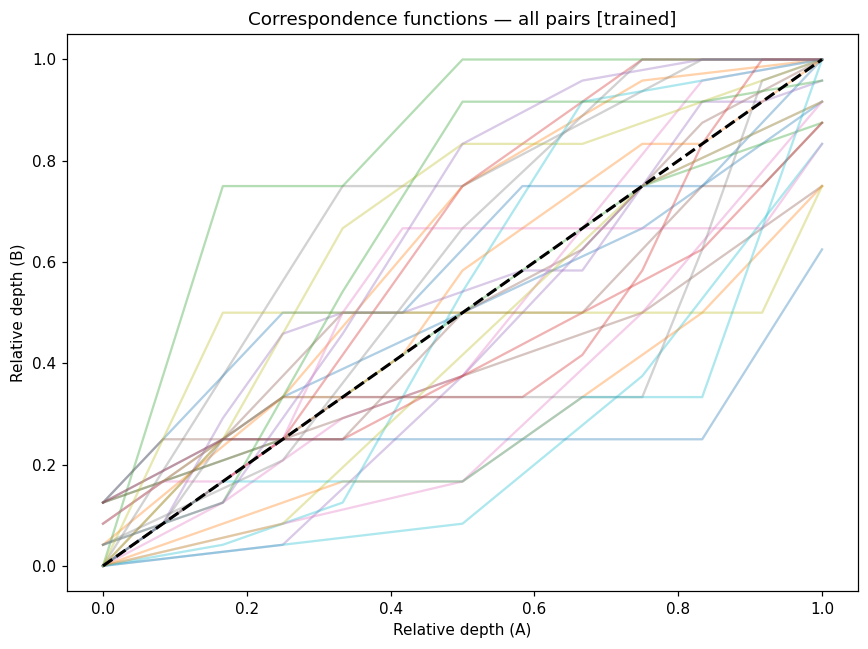


[PRIMARY] Composition error (affine-only): mean=0.2052 ± 0.1233  (n=120 triples)


,A,B,C,composition_error
30,ar_affine_021M,mae_affine_001M,mae_affine_021M,0.034798
22,ar_affine_021M,ar_affine_001M,mae_affine_021M,0.041812
44,ar_affine_100M,ar_affine_021M,ar_affine_001M,0.042339
63,mae_affine_001M,ar_affine_001M,mae_affine_100M,0.044391
14,ar_affine_001M,mae_affine_021M,mae_affine_001M,0.045117
66,mae_affine_001M,ar_affine_021M,mae_affine_021M,0.051056
24,ar_affine_021M,ar_affine_100M,ar_affine_001M,0.051170
9,ar_affine_001M,mae_affine_001M,ar_affine_100M,0.053318
48,ar_affine_100M,mae_affine_001M,ar_affine_001M,0.058116
6,ar_affine_001M,ar_affine_100M,mae_affine_021M,0.062370


In [8]:
# --- Run universality: AFFINE-ONLY PRIMARY, then full grid as secondary ----
# Primary result: affine-only subgraph (ar_affine vs mae_affine, all 3 scales).
# 6 models -> 30 ordered pairs. Cheap, runs first, avoids the AIM confound.

SAVE_DIR = Path("./dr_figures"); SAVE_DIR.mkdir(exist_ok=True)

AFFINE_MODELS = [m for m in MODELS if "affine" in m]
print(f"Primary (affine-only) subgraph: {AFFINE_MODELS}")

results_trained_affine = run_all_pairs(AFFINE_MODELS, tag="trained", save_dir=SAVE_DIR, show=False)
overlay_plot(results_trained_affine, tag="trained", save_path=SAVE_DIR / "overlay_trained_affine.pdf")

comp_df_affine = composition_table(results_trained_affine, AFFINE_MODELS)
print(f"\n[PRIMARY] Composition error (affine-only): mean={comp_df_affine.composition_error.mean():.4f} "
      f"± {comp_df_affine.composition_error.std():.4f}  (n={len(comp_df_affine)} triples)")
comp_df_affine.head(10)


[trained] ar_affine_001M -> ar_affine_021M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[trained] ar_affine_001M -> ar_affine_100M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[trained] ar_affine_001M -> ar_aim_001M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[trained] ar_affine_001M -> ar_aim_021M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  sub

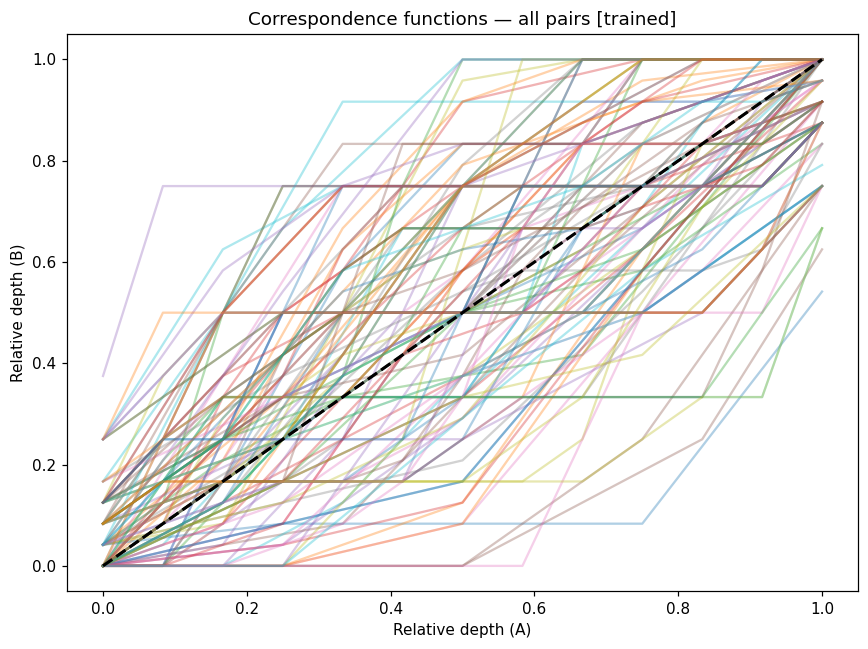


[SECONDARY / confounded] Composition error (full grid, incl. AIM): mean=0.2106 ± 0.1206


,A,B,C,composition_error
131,ar_affine_021M,ar_aim_001M,ar_affine_100M,0.010763
1105,mae_aim_021M,ar_affine_001M,mae_affine_001M,0.011275
240,ar_affine_100M,ar_aim_001M,ar_affine_001M,0.011441
1196,mae_aim_021M,mae_aim_001M,mae_affine_001M,0.015890
83,ar_affine_001M,mae_aim_001M,ar_aim_021M,0.015901
277,ar_affine_100M,mae_affine_001M,mae_aim_001M,0.021572
1212,mae_aim_100M,ar_affine_001M,ar_aim_001M,0.026310
3,ar_affine_001M,ar_affine_021M,ar_aim_100M,0.027706
1050,mae_aim_001M,mae_affine_001M,ar_affine_001M,0.030628
209,ar_affine_021M,mae_aim_021M,mae_aim_100M,0.030953


In [9]:
# --- Run universality for the TRAINED models (SECONDARY, confounded) -------
# NOTE: this is O(n_models^2) alignment matrices, each O(L^2) MKNN calls with
# permutation nulls -- this is the FULL 12-model grid (3 scales x 4 families),
# 132 ordered pairs. At 100M (14 layers) this is 14*14*N_NULL MKNN calls per
# pair, so this cell can take a while -- consider running it unattended.
#
# This full grid includes AIM pairs, which are confounded by AIM's extra
# per-modality layers (see markdown above). Treat this as the secondary,
# confounded comparison -- the affine-only run above is the primary result.

ALL_MODELS = MODELS  # full 12-model grid: 3 scales x 4 families

results_trained = run_all_pairs(ALL_MODELS, tag="trained", save_dir=SAVE_DIR, show=False)
overlay_plot(results_trained, tag="trained", save_path=SAVE_DIR / "overlay_trained.pdf")

comp_df_trained = composition_table(results_trained, ALL_MODELS)
print(f"\n[SECONDARY / confounded] Composition error (full grid, incl. AIM): "
      f"mean={comp_df_trained.composition_error.mean():.4f} "
      f"± {comp_df_trained.composition_error.std():.4f}")
comp_df_trained.head(10)


## 7. Step 6 — Controls

- **Untrained (random-init) control.** Run the identical pipeline on the
  `untrained` tag (step-0 checkpoints, or seeded scratch-init fallback per
  `extract_layerwise_colm.py`'s `fetch_untrained`). Any correspondence that
  survives here reflects architecture/input-statistics effects, not learning.
- **Pixel-PCA Layer 0.** Already threaded through `run_pair` above as the green
  dashed "+pixel-PCA node" curve — a raw-pixel PCA control inserted as a real
  graph node, serving as the sanity check that the recovered ridge isn't an
  artifact of endpoint-anchoring.


[untrained] ar_affine_001M -> ar_affine_021M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] ar_affine_001M -> ar_affine_100M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] ar_affine_001M -> mae_affine_001M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] ar_affine_001M -> mae_affine_021M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 re

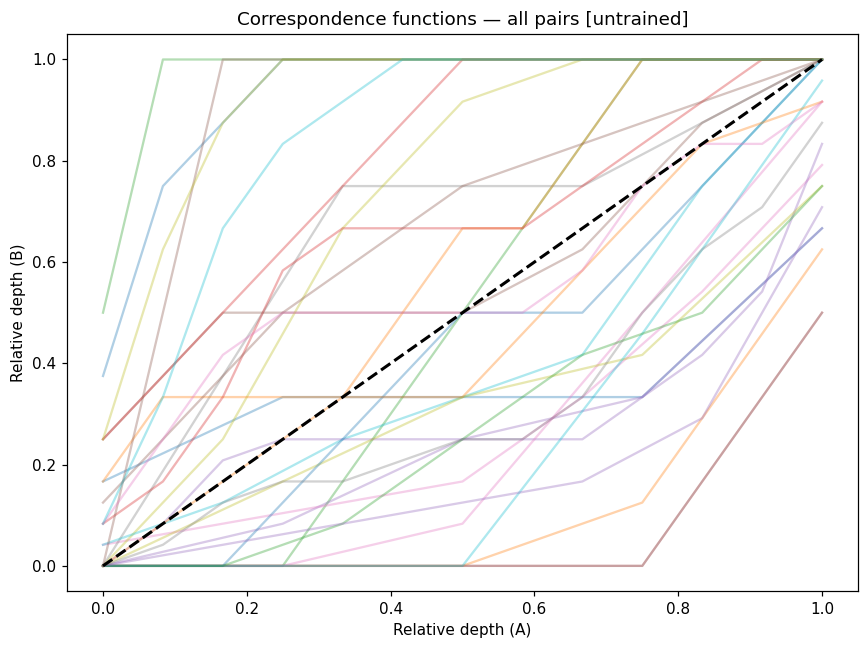

[PRIMARY] Composition error (affine-only, untrained): mean=0.2002 ± 0.1297
[untrained] ar_affine_001M -> ar_affine_021M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] ar_affine_001M -> ar_affine_100M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] ar_affine_001M -> ar_aim_001M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] ar_affine_001M -> ar_aim_021M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5

C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)


  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] mae_aim_001M -> mae_affine_001M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] mae_aim_001M -> mae_affine_021M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] mae_aim_001M -> mae_affine_100M
  row 1/5 (encoder)
  row 2/5 (h.00)
  row 3/5 (h.01)
  row 4/5 (h.02)
  row 5/5 (h.03)
  subsample size=5: 10 repeats done
  subsample size=10: 10 repeats done
  subsample size=20: 10 repeats done
  subsample size=50: 10 repeats done
[untrained] mae_

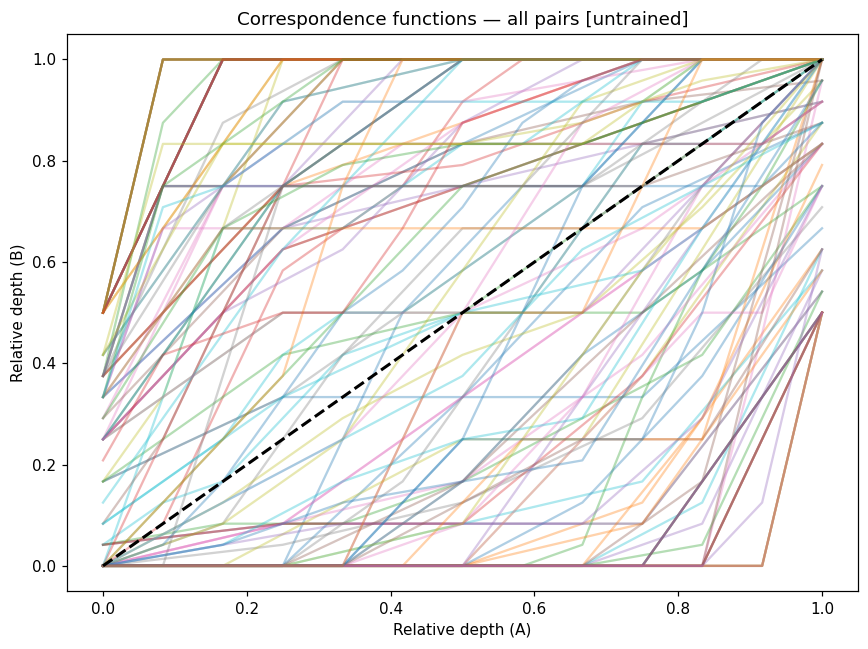

[SECONDARY / confounded] Composition error (full grid, untrained): mean=0.2484 ± 0.1898


,pair,rho_trained,rho_untrained,deviation_trained,deviation_untrained
1,ar_affine_001M→ar_affine_100M,1.000000,-0.111803,0.140625,0.390625
11,ar_affine_100M→ar_affine_021M,0.942813,0.799696,0.052083,0.131944
0,ar_affine_001M→ar_affine_021M,0.900000,-0.100000,0.062500,0.229167
18,mae_affine_001M→mae_affine_021M,0.900000,0.000000,0.072917,0.177083
24,mae_affine_021M→mae_affine_100M,0.828862,0.872872,0.163194,0.322917
16,mae_affine_001M→ar_affine_021M,0.820783,-0.105409,0.197917,0.239583
21,mae_affine_021M→ar_affine_021M,0.815374,0.852437,0.229167,0.048611
20,mae_affine_021M→ar_affine_001M,0.804617,0.436436,0.277778,0.083333
3,ar_affine_001M→mae_affine_021M,0.700000,-0.700000,0.125000,0.437500
14,ar_affine_100M→mae_affine_100M,0.683281,0.606669,0.067708,0.215278


In [10]:
# --- 7. Untrained control: affine-only PRIMARY, full grid SECONDARY ----------
# Run on affine-only first (matches the primary trained run), then full grid
# for the confounded comparison. mono_untrained (used by summarize()) comes
# from the affine untrained run so the trained vs untrained rho comparison is
# apples-to-apples.

# PRIMARY: affine-only untrained
results_untrained_affine = run_all_pairs(AFFINE_MODELS, tag="untrained", save_dir=SAVE_DIR, show=False)
overlay_plot(results_untrained_affine, tag="untrained", save_path=SAVE_DIR / "overlay_untrained_affine.pdf")

comp_df_untrained_affine = composition_table(results_untrained_affine, AFFINE_MODELS)
print(f"[PRIMARY] Composition error (affine-only, untrained): "
      f"mean={comp_df_untrained_affine.composition_error.mean():.4f} "
      f"± {comp_df_untrained_affine.composition_error.std():.4f}")

# SECONDARY: full grid untrained (confounded, includes AIM)
results_untrained = run_all_pairs(ALL_MODELS, tag="untrained", save_dir=SAVE_DIR, show=False)
overlay_plot(results_untrained, tag="untrained", save_path=SAVE_DIR / "overlay_untrained_full.pdf")

comp_df_untrained = composition_table(results_untrained, ALL_MODELS)
print(f"[SECONDARY / confounded] Composition error (full grid, untrained): "
      f"mean={comp_df_untrained.composition_error.mean():.4f} "
      f"± {comp_df_untrained.composition_error.std():.4f}")

# Side-by-side rho: trained vs untrained, affine pairs only (apples-to-apples)
rho_compare = pd.DataFrame([
    {"pair": f"{a}\u2192{b}",
     "rho_trained":    results_trained_affine[(a, b)]["rho"],
     "rho_untrained":  results_untrained_affine.get((a, b), {}).get("rho", float("nan")),
     "deviation_trained":   results_trained_affine[(a, b)]["deviation_area"],
     "deviation_untrained": results_untrained_affine.get((a, b), {}).get("deviation_area", float("nan"))}
    for (a, b) in results_trained_affine
])
rho_compare.sort_values("rho_trained", ascending=False)


## 9. Trained vs Untrained Overlay — same pairs, side-by-side

For each model pair, plot the DTW correspondence curve under the **trained** and
**untrained** checkpoints on the same axes. If the trained curve is substantially
closer to the diagonal (or more consistent across pairs), the ridge is learned
structure. If both curves look similar, the correspondence is dominated by
architecture / input-statistics rather than training.

Reading guide:
- **Blue solid** — trained correspondence φ.
- **Orange dashed** — untrained (random-init) correspondence φ.
- **Black dashed diagonal** — φ = identity, i.e. both models pace identically.
- A trained curve hugging the diagonal more tightly than the untrained one means
  training *creates* the alignment. Untrained curves that already hug the diagonal
  suggest the architecture alone imposes the ordering.

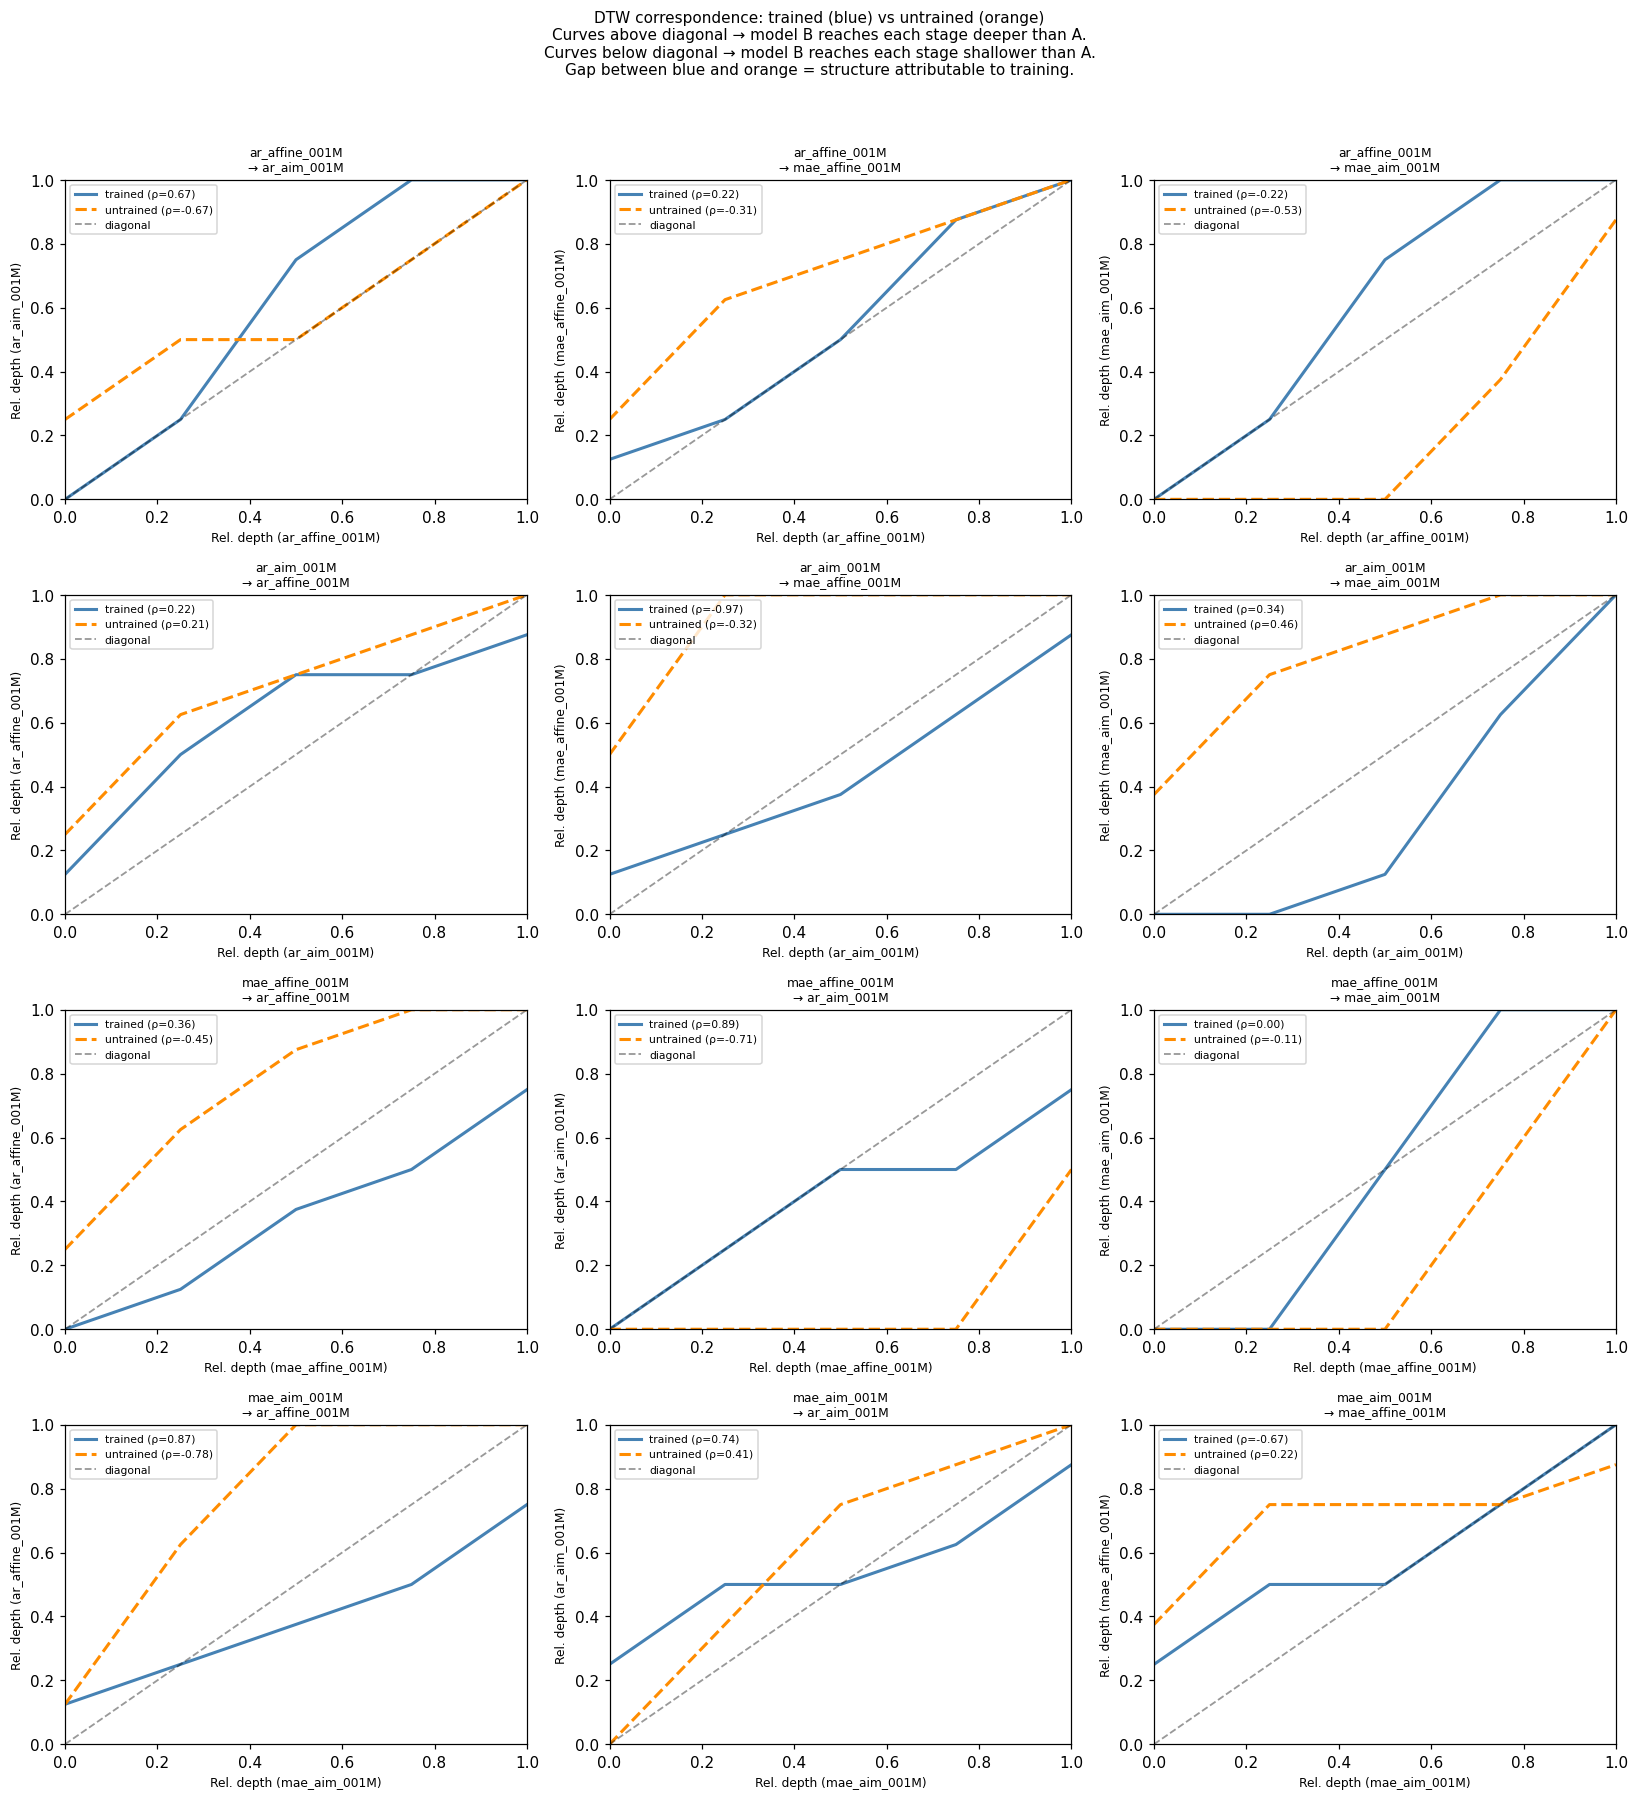

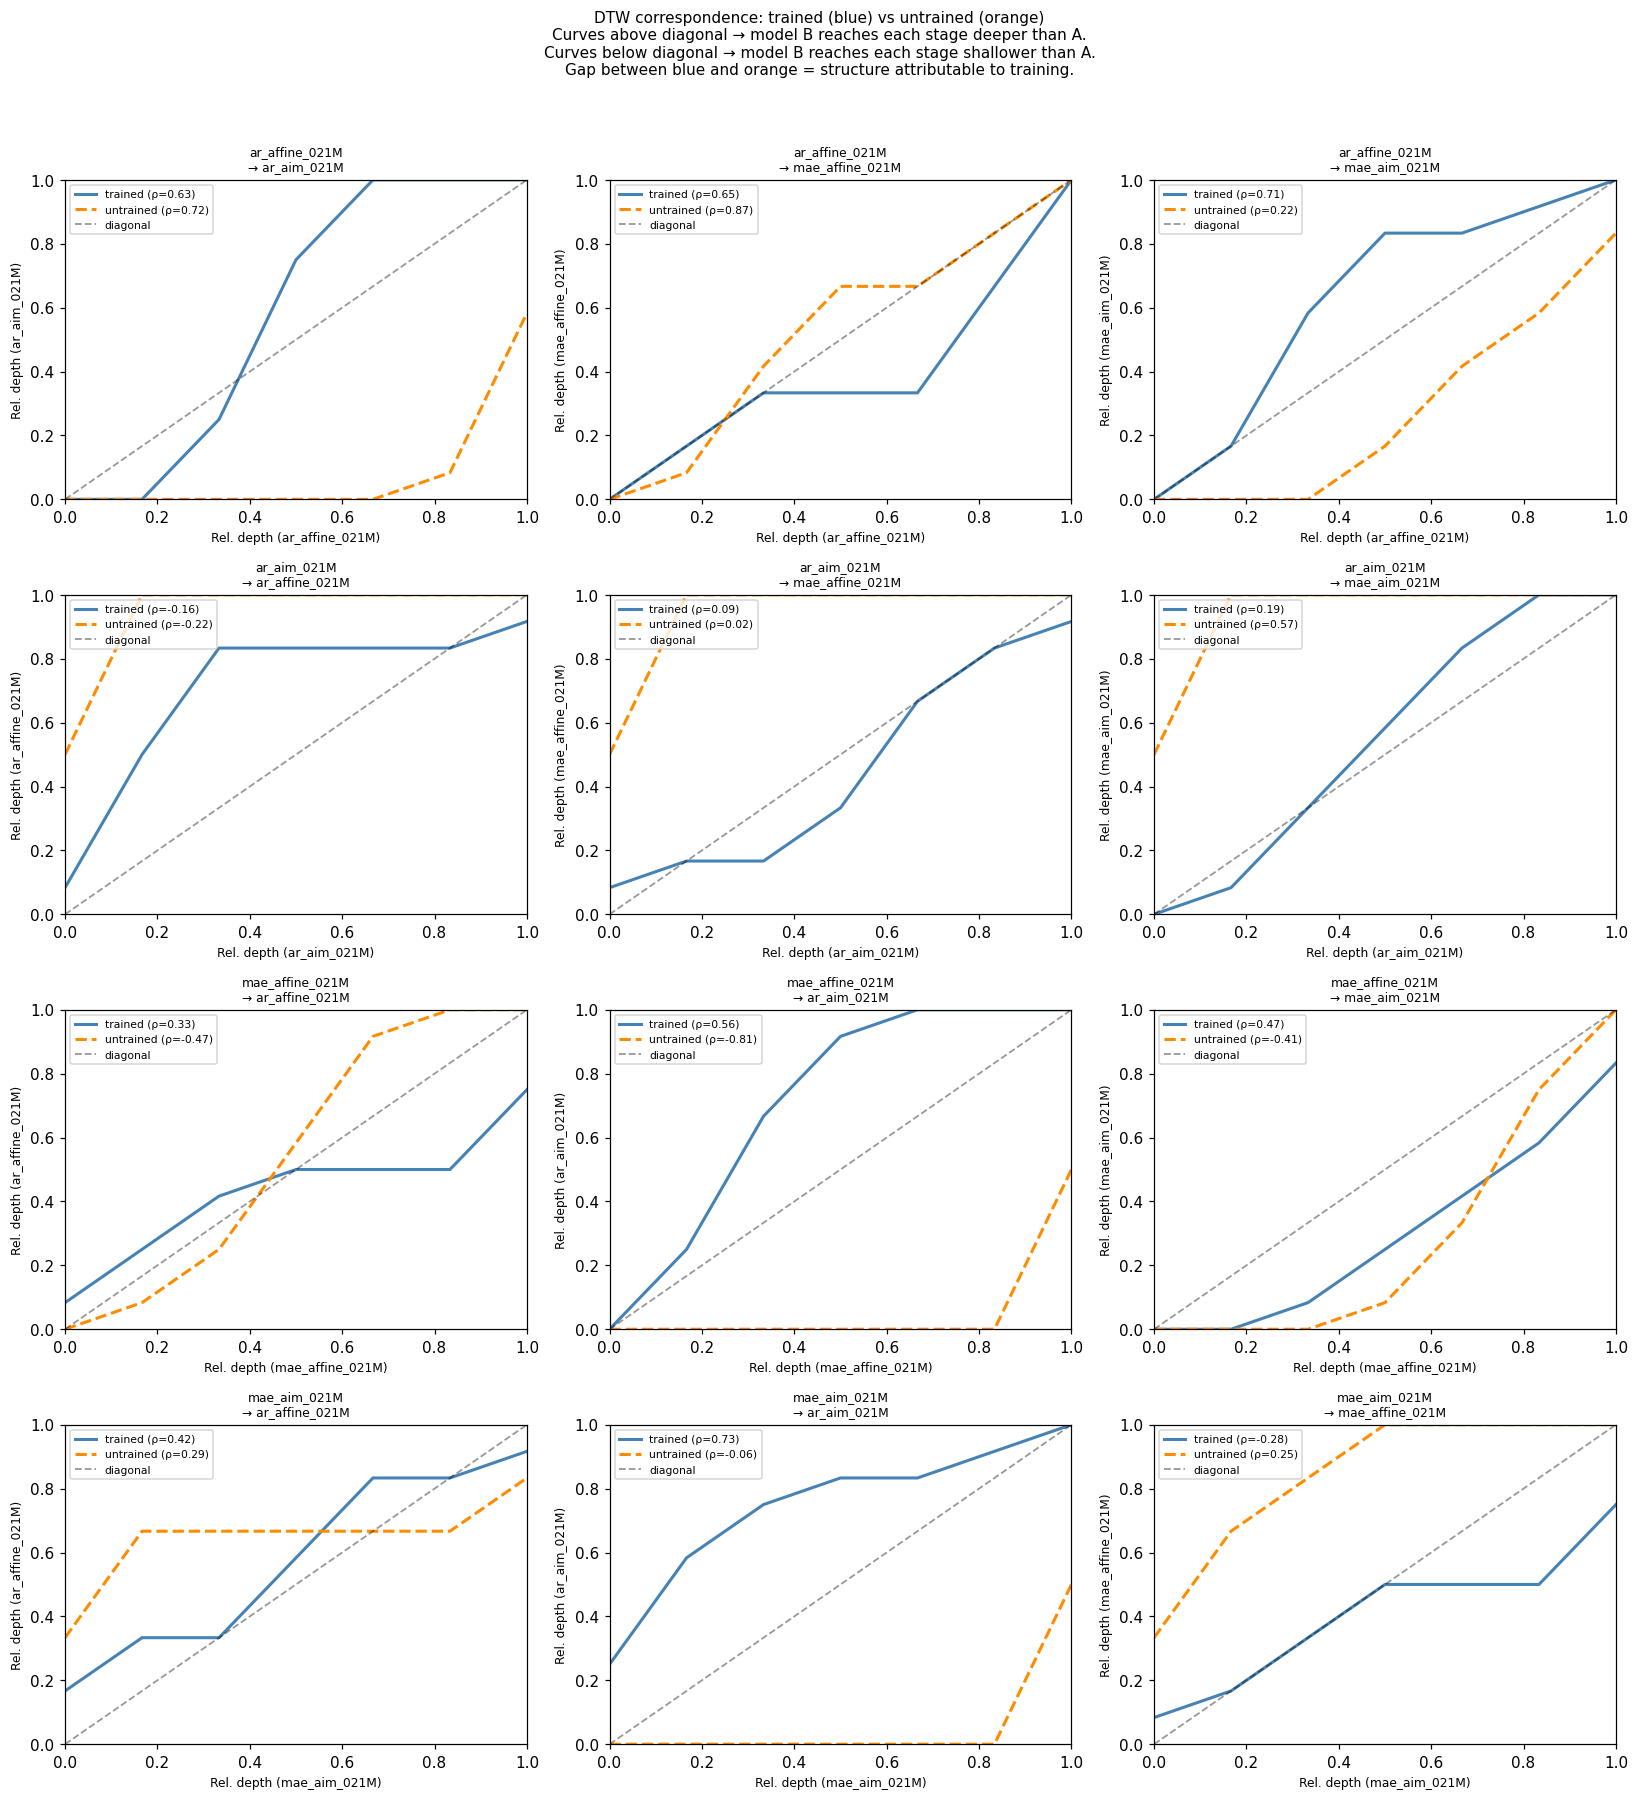

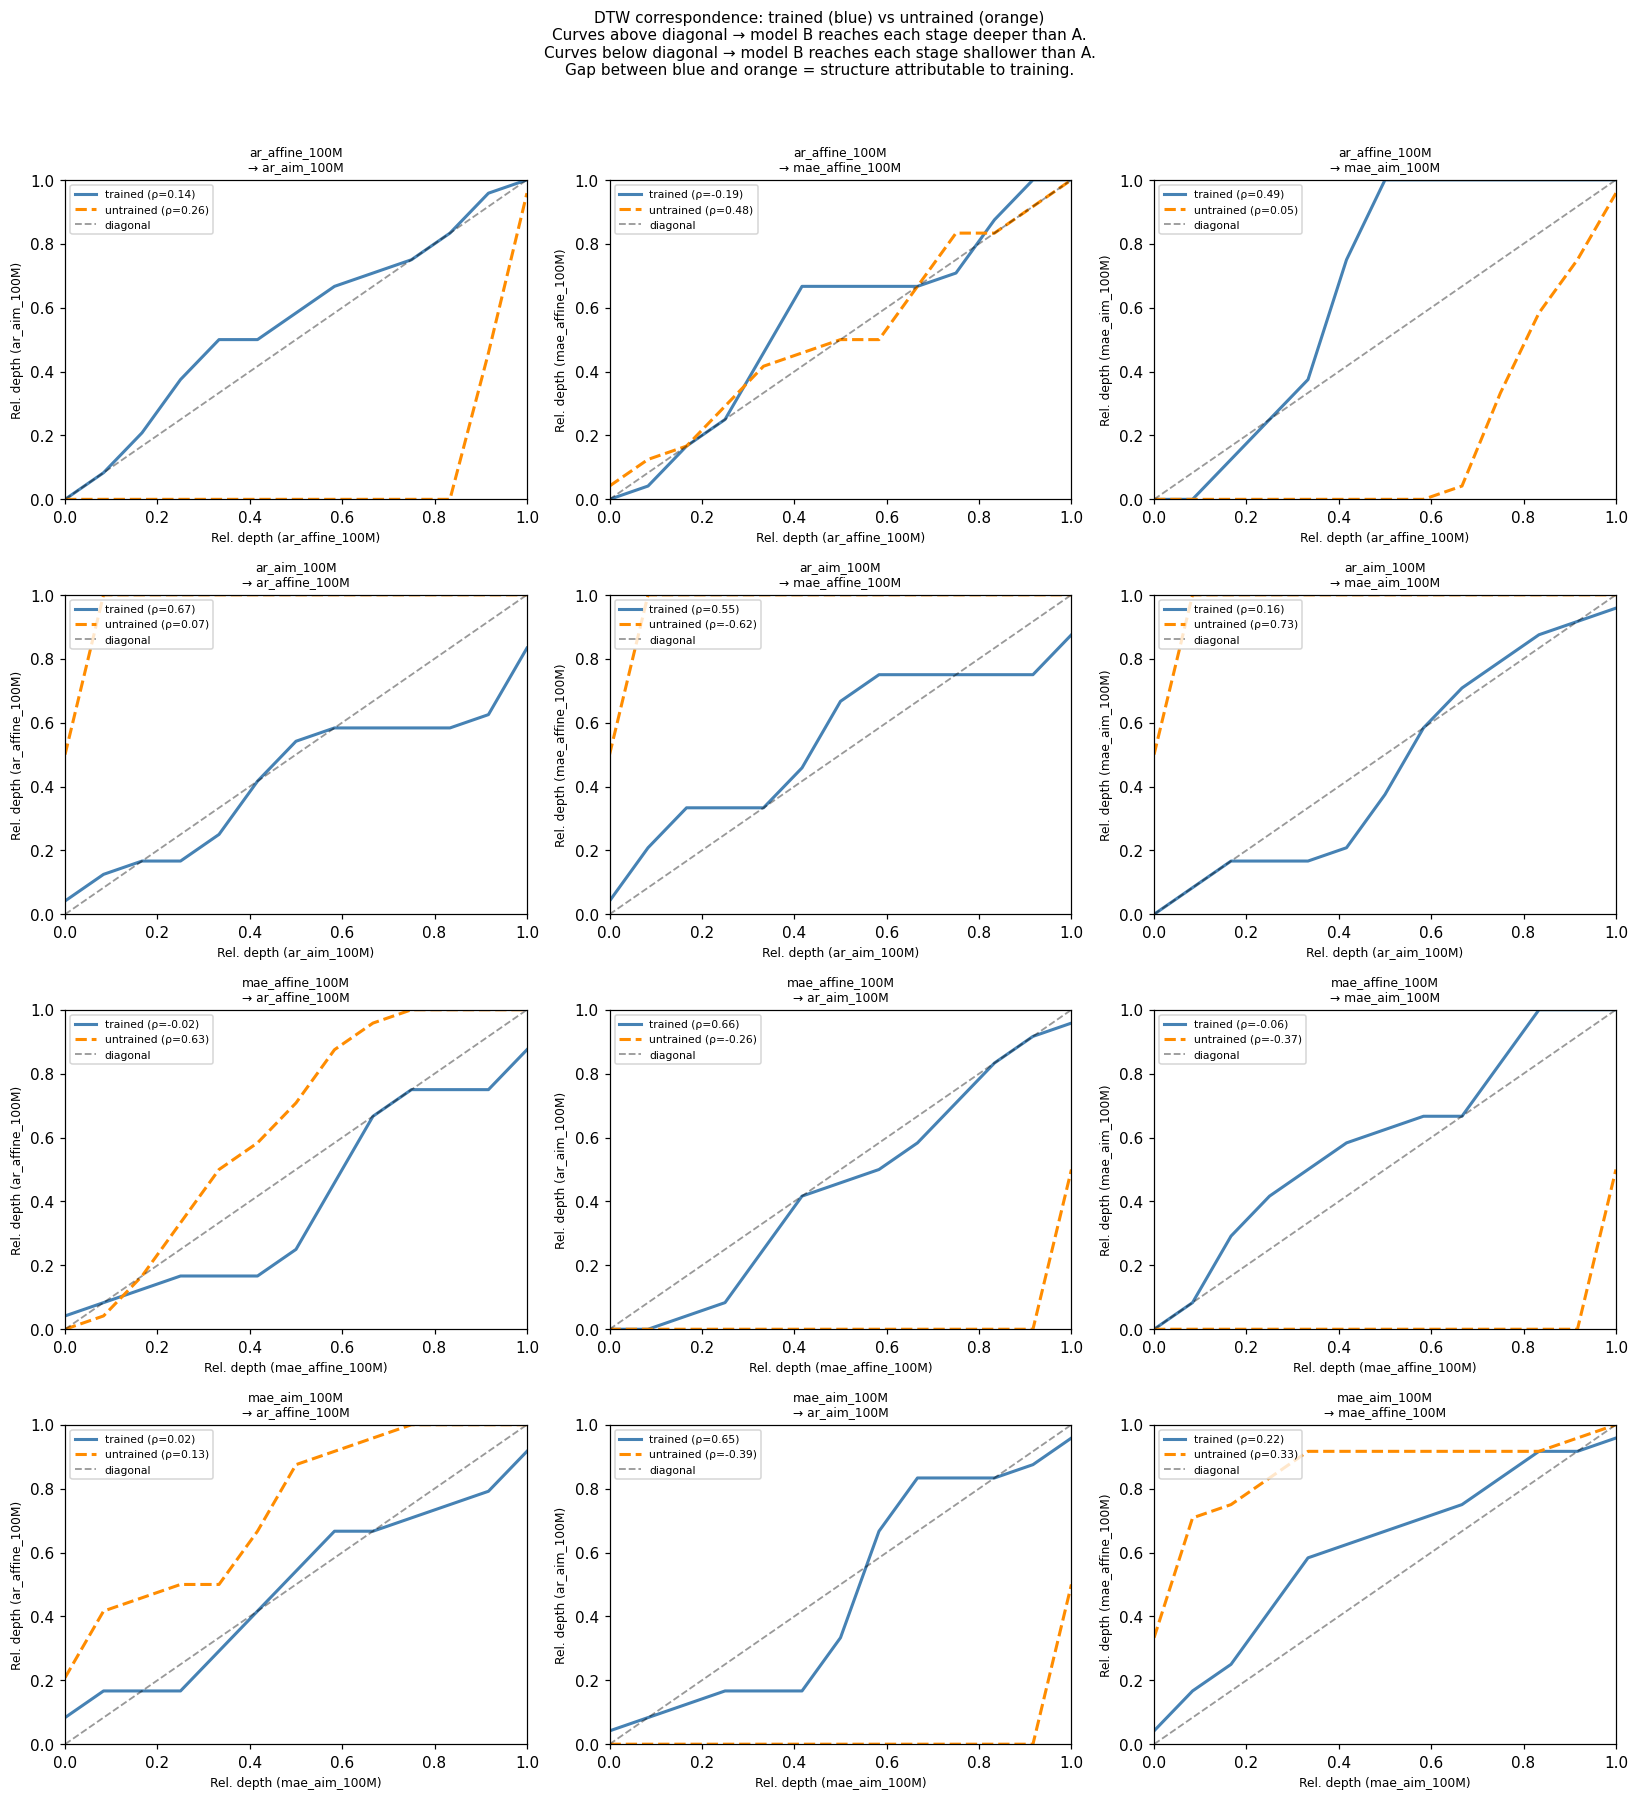

In [11]:
# --- 9. Trained vs Untrained overlay, one panel per pair -------------------
# With the full 12-model grid there are 132 ordered pairs -- one giant figure
# is unreadable, so this plots per-scale sub-grids (4 families x 4 families =
# 12 pairs each) by default. Pass pairs_subset explicitly to plot any other
# slice (e.g. a single family across scales).

def plot_trained_vs_untrained(
    results_trained: dict,
    results_untrained: dict,
    save_path: "Path | None" = None,
    ncols: int = 3,
    pairs_subset: "list | None" = None,
) -> None:
    """
    One subplot per ordered (A, B) pair.
    Blue solid  = trained correspondence.
    Orange dash = untrained correspondence (shown only when available).
    Diagonal = identity baseline.
    Title shows rho for both tags so you can spot the numerical gap at a glance.

    pairs_subset: optional list of (A, B) tuples to restrict plotting to
    (defaults to every pair in results_trained).
    """
    pairs = pairs_subset if pairs_subset is not None else list(results_trained.keys())
    n = len(pairs)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                              squeeze=False)

    for idx, (a, b) in enumerate(pairs):
        ax = axes[idx // ncols][idx % ncols]
        r_t = results_trained[(a, b)]
        phi_t = r_t["phi"]
        rel_t = np.linspace(0, 1, len(phi_t))

        ax.plot(rel_t, phi_t, color="steelblue", lw=2, label=f"trained (ρ={r_t['rho']:.2f})")

        if (a, b) in results_untrained:
            r_u = results_untrained[(a, b)]
            phi_u = r_u["phi"]
            rel_u = np.linspace(0, 1, len(phi_u))
            ax.plot(rel_u, phi_u, color="darkorange", lw=2, ls="--",
                    label=f"untrained (ρ={r_u['rho']:.2f})")

        ax.plot([0, 1], [0, 1], "k--", alpha=0.4, lw=1.2, label="diagonal")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel(f"Rel. depth ({a})", fontsize=8)
        ax.set_ylabel(f"Rel. depth ({b})", fontsize=8)
        ax.set_title(f"{a}\n→ {b}", fontsize=8)
        ax.legend(fontsize=7, loc="upper left")

    # hide unused axes
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("DTW correspondence: trained (blue) vs untrained (orange)\n"
                 "Curves above diagonal → model B reaches each stage deeper than A.\n"
                 "Curves below diagonal → model B reaches each stage shallower than A.\n"
                 "Gap between blue and orange = structure attributable to training.",
                 fontsize=10, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


# Full grid, split into one sub-grid per scale (12 pairs each, readable).
for scale in SCALES:
    scale_pairs = [(a, b) for (a, b) in results_trained
                   if a.endswith(scale) and b.endswith(scale)]
    if not scale_pairs:
        continue
    plot_trained_vs_untrained(
        results_trained,
        results_untrained,
        save_path=SAVE_DIR / f"trained_vs_untrained_{scale}.pdf",
        pairs_subset=scale_pairs,
    )


## 10. Combined Heatmap Grid — all model pairs

A single figure tiling the MKNN alignment heatmaps for every ordered (A, B) pair
in the benchmark. The DTW anchored path is overlaid on each panel in red, and the
open-ended path in white dotted. Panels are arranged in a matrix:
**rows = model A, columns = model B** (diagonal is blank — same model).

Use this to spot at a glance:
- Which pairs have a strong diagonal ridge (bright σ band along the diagonal)
  vs. diffuse or off-diagonal brightness.
- Pairs where the red DTW path deviates heavily from the diagonal (unequal pacing).
- Outlier pairs where the heatmap looks structurally different from the rest.

C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3443078613.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


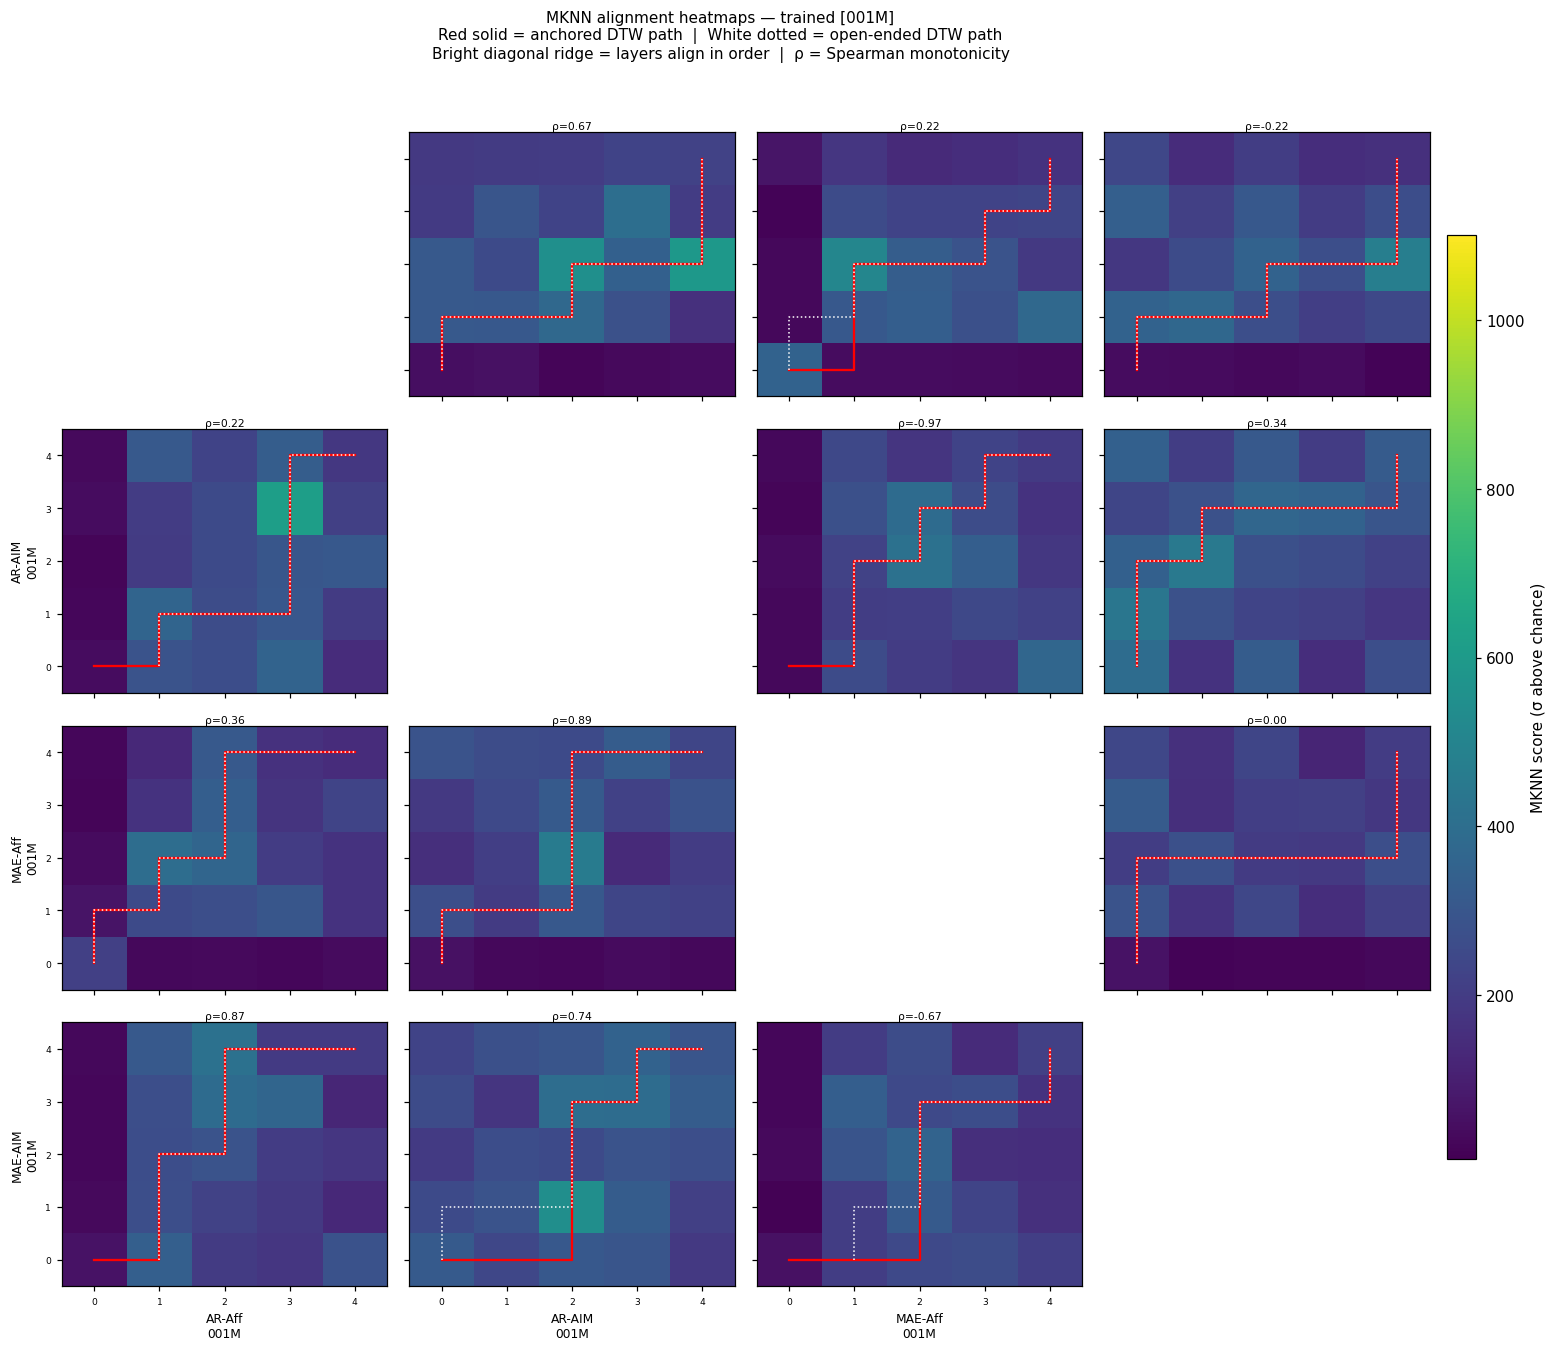

C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3443078613.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


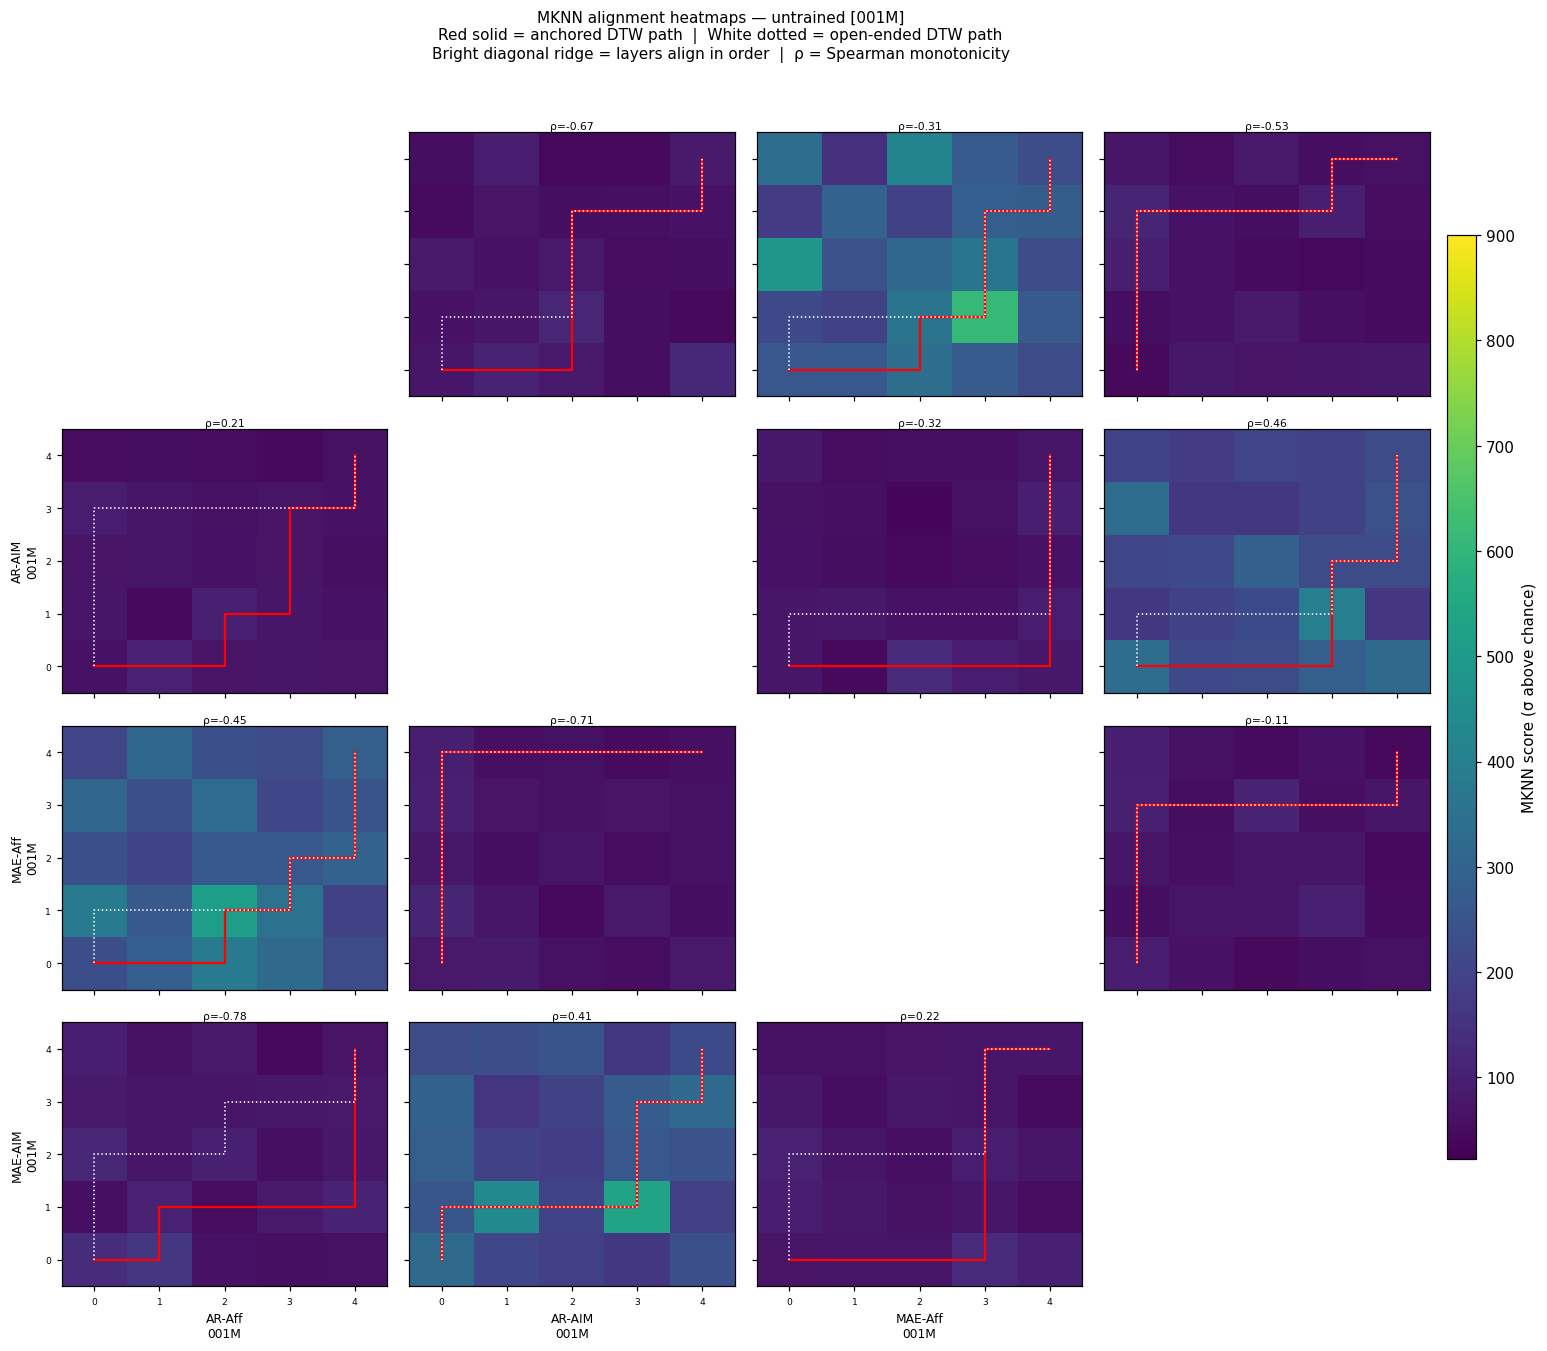

C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3443078613.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


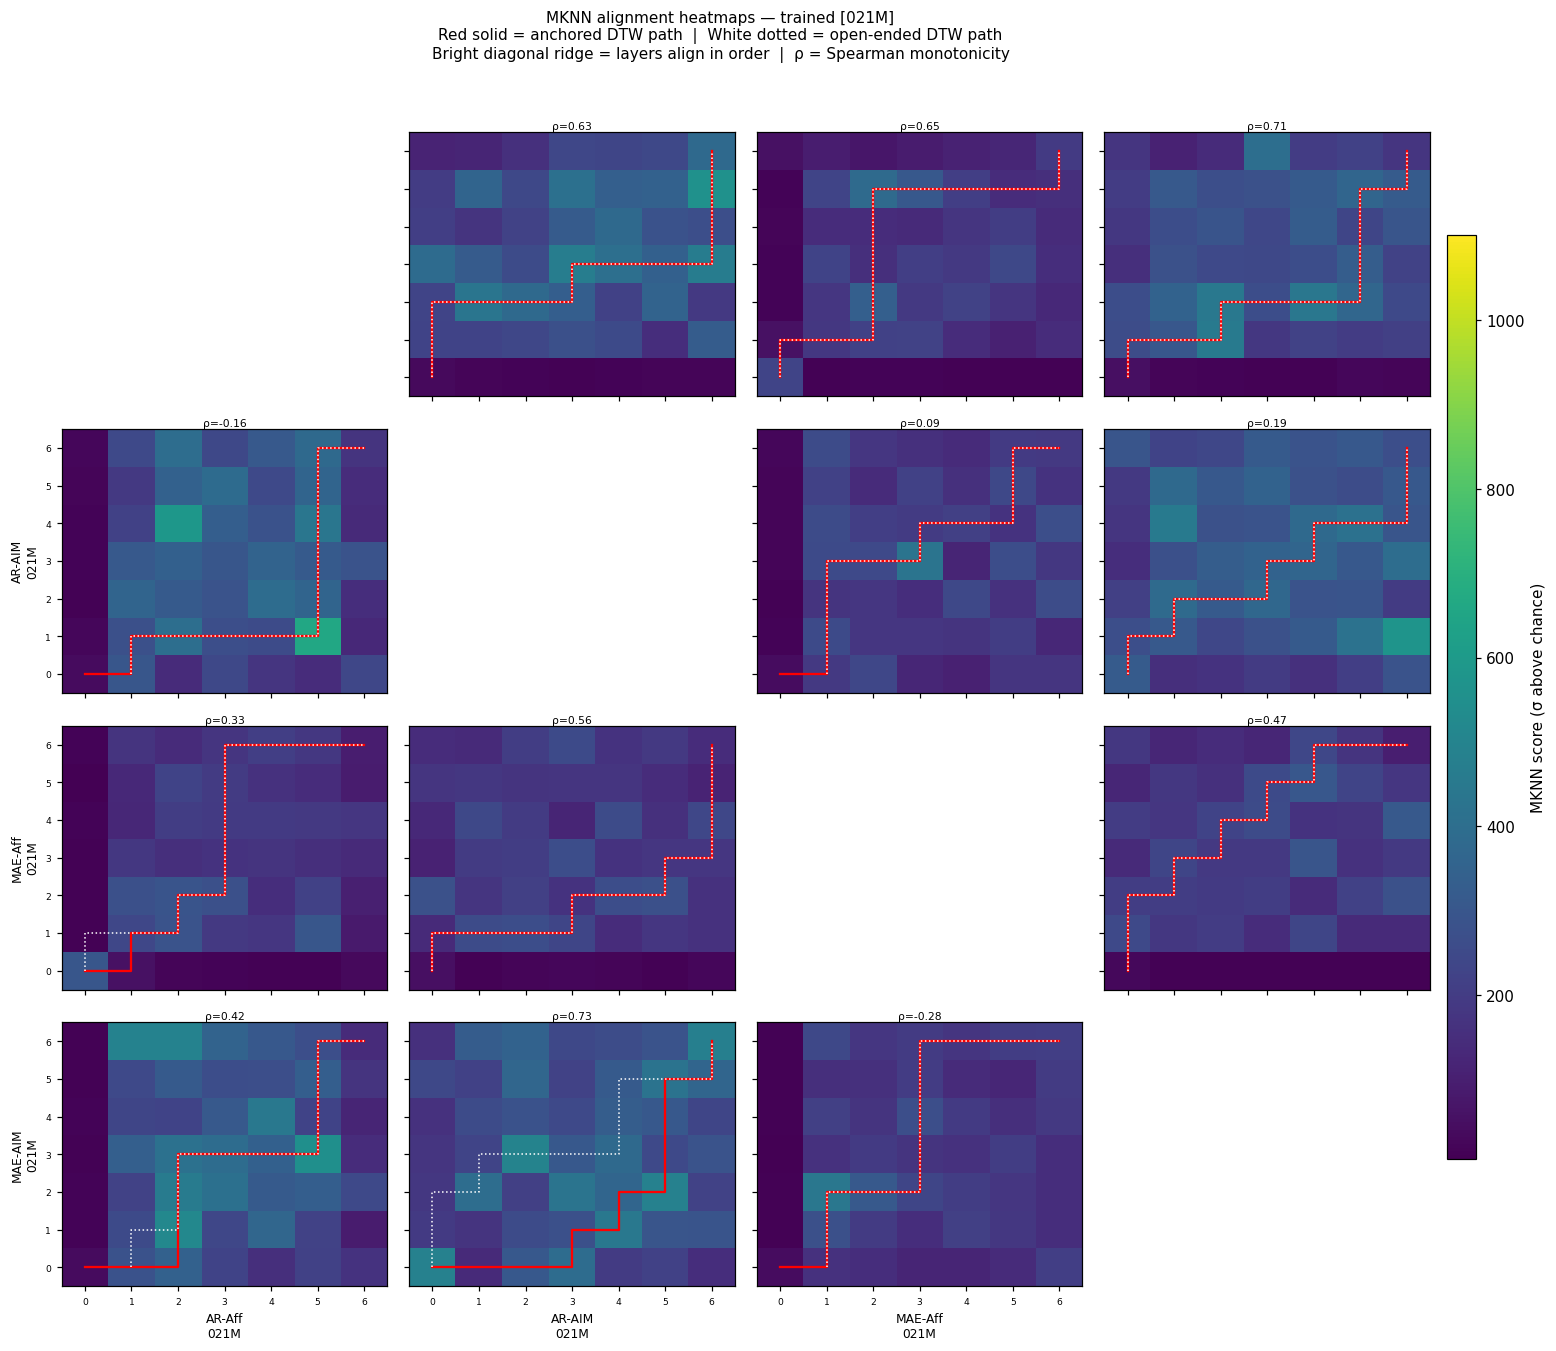

C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3443078613.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


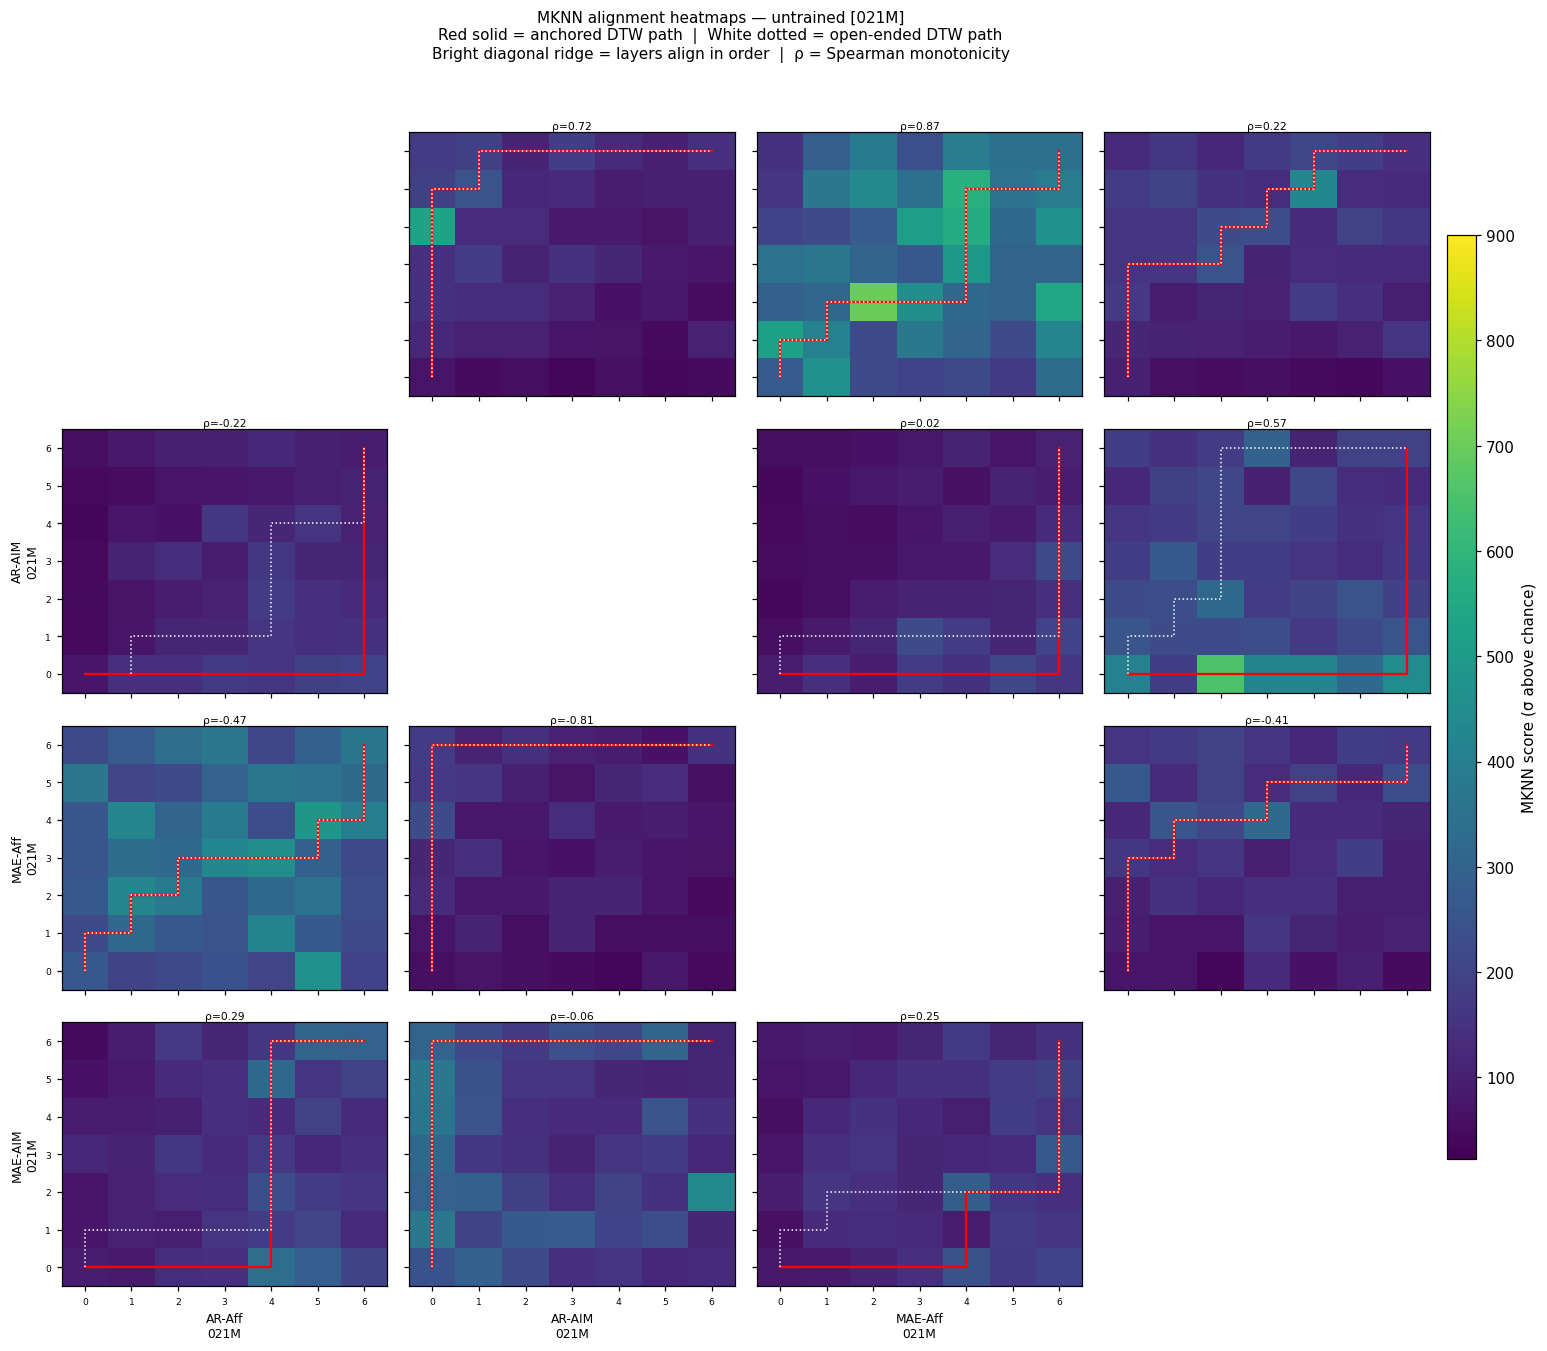

C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3443078613.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


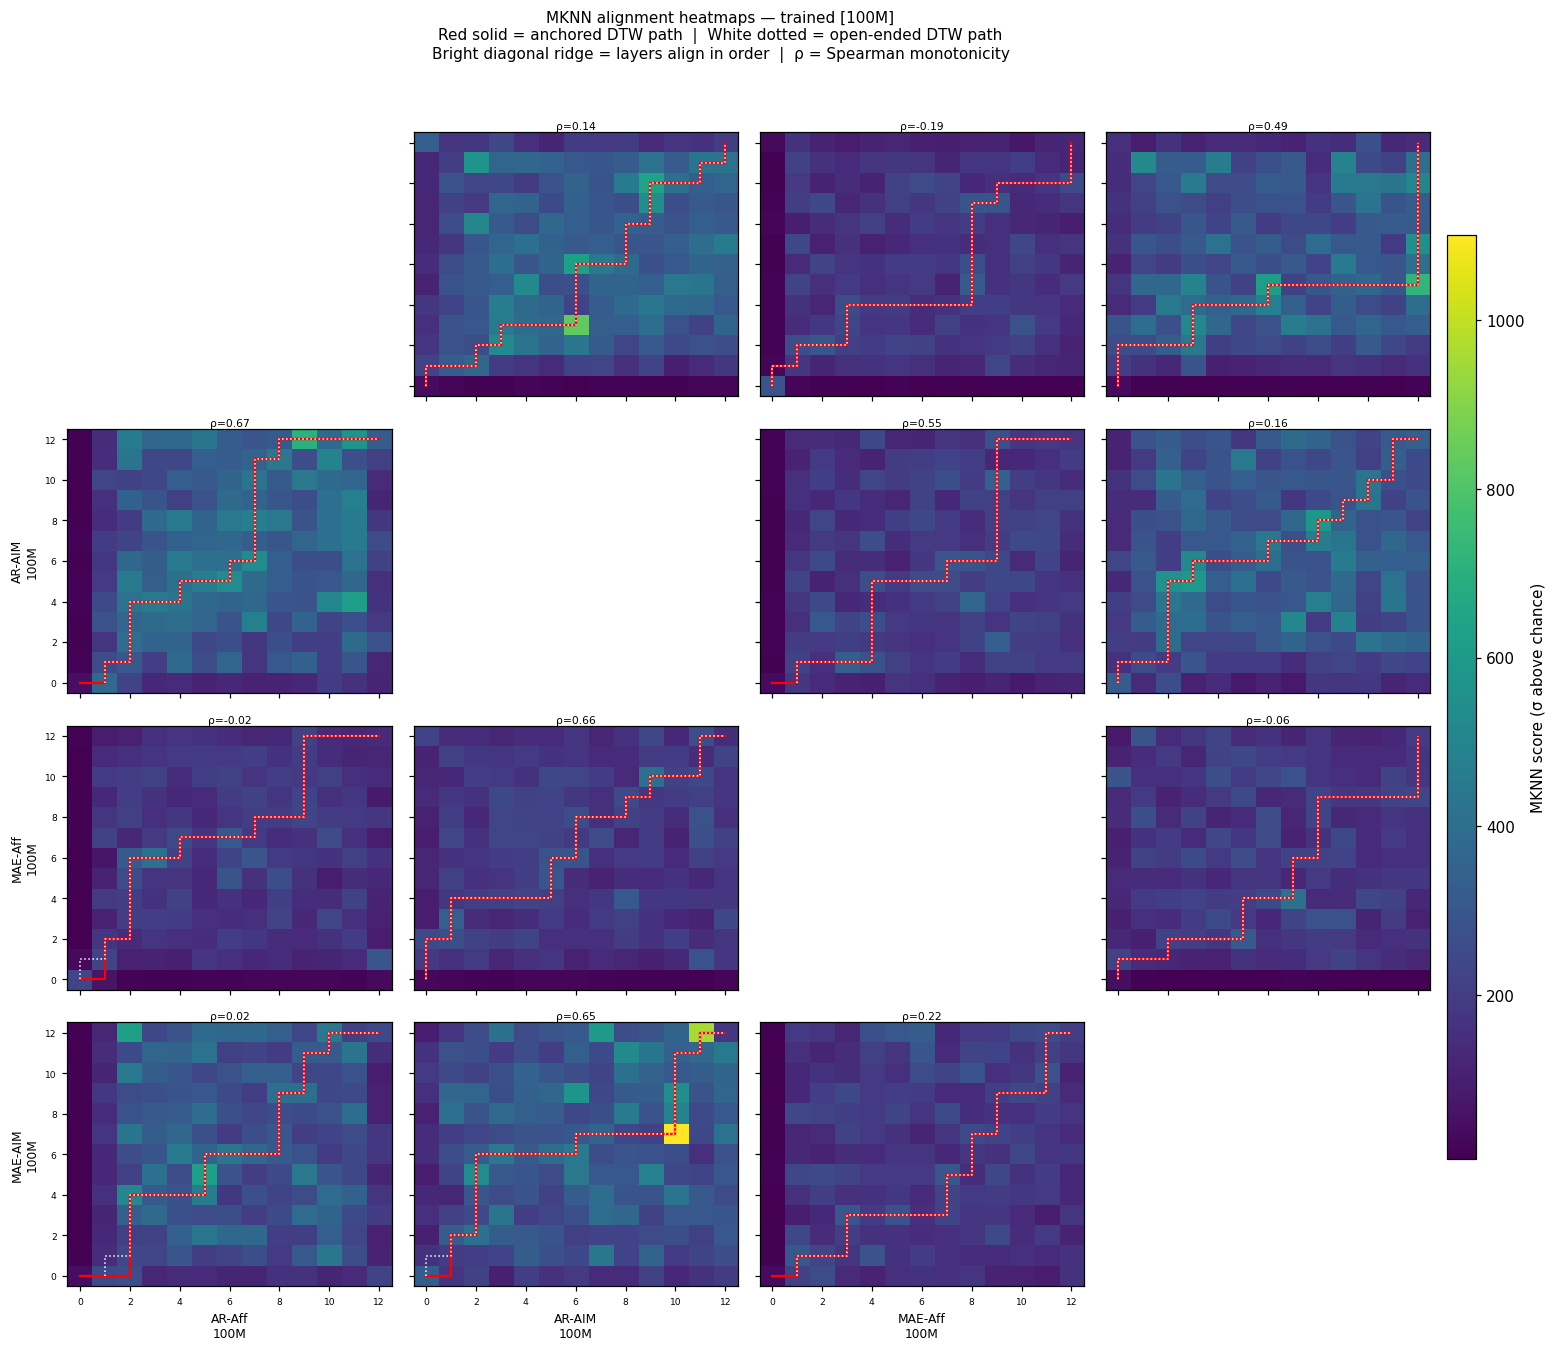

C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3443078613.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


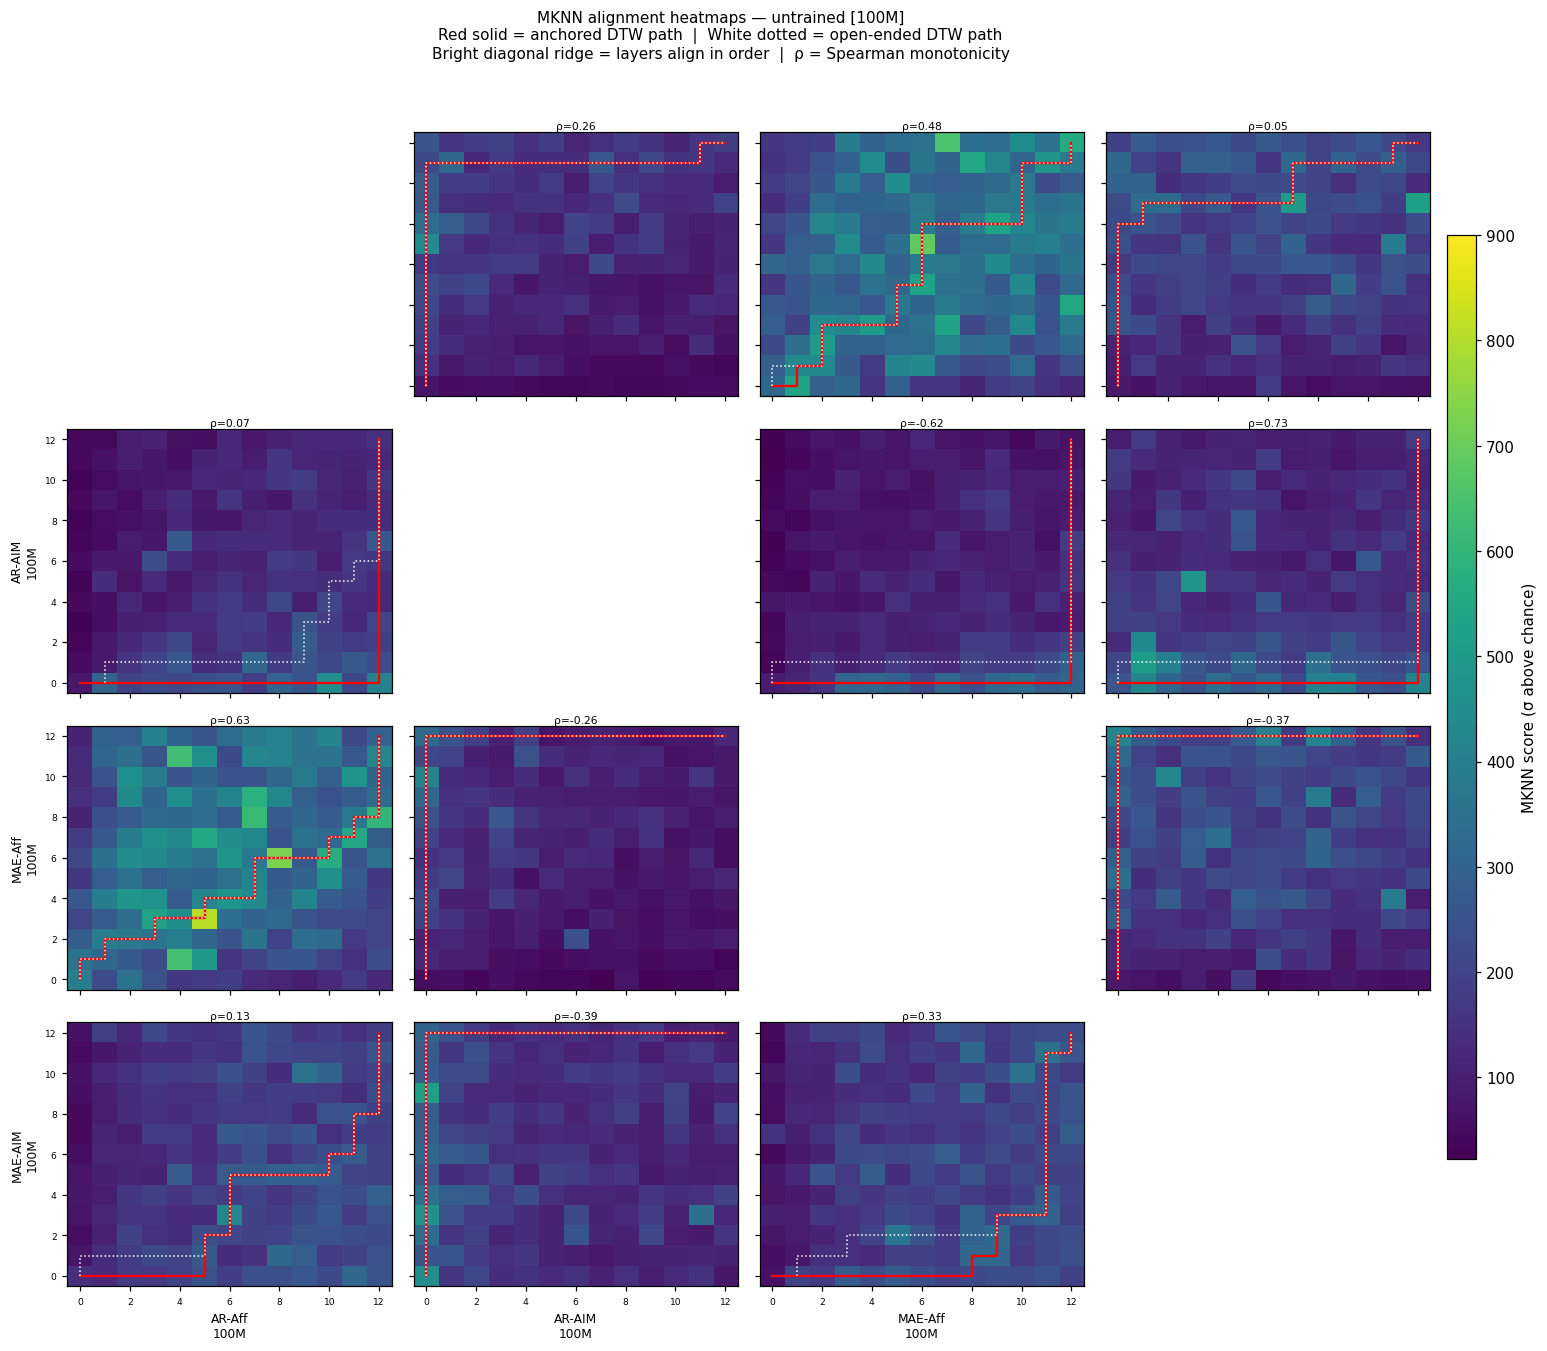

In [12]:
# --- 10. Big combined heatmap grid -----------------------------------------
# Full grid = 12x12 = 144 panels, illegible as one figure. Default to one
# 4x4 (per-scale, all 4 families) sub-grid per scale instead. Pass an
# explicit `models` list to combined_heatmap_grid for any other slice.

def combined_heatmap_grid(
    all_results: dict,
    models: list,
    tag: str = "trained",
    save_path: "Path | None" = None,
    panel_size: float = 3.0,
    vmin: "float | None" = None,
    vmax: "float | None" = None,
) -> None:
    """
    NxN grid where entry (row=i, col=j) shows the MKNN heatmap for models[i] vs
    models[j] with the anchored DTW path in red. Diagonal panels are left blank.
    A shared colorbar is placed to the right.
    """
    n = len(models)
    fig, axes = plt.subplots(
        n, n,
        figsize=(panel_size * n + 1.2, panel_size * n),
        squeeze=False,
    )

    # collect global vmin/vmax if not provided
    all_M = [v["M"] for v in all_results.values()]
    _vmin = vmin if vmin is not None else min(m.min() for m in all_M)
    _vmax = vmax if vmax is not None else max(m.max() for m in all_M)

    im_ref = None
    for row, a in enumerate(models):
        for col, b in enumerate(models):
            ax = axes[row][col]
            if a == b:
                ax.set_visible(False)
                continue
            if (a, b) not in all_results:
                ax.text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=8,
                        transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                continue

            r = all_results[(a, b)]
            M = r["M"]
            im = ax.imshow(M, origin="lower", aspect="auto",
                           cmap="viridis", vmin=_vmin, vmax=_vmax)
            im_ref = im

            # recompute DTW paths directly from stored M
            cost = 1.0 - M
            path_a = dtw_path_anchored(cost)
            path_o = dtw_path_open_ended(cost)
            pi, pj   = zip(*path_a)
            poi, poj = zip(*path_o)
            ax.plot(pj, pi, "r-", lw=1.5)
            ax.plot(poj, poi, color="white", ls=":", lw=1.0)

            rho = r["rho"]
            ax.set_title(f"ρ={rho:.2f}", fontsize=7, pad=2)

            # axis labels only on edges
            if row == n - 1:
                ax.set_xlabel(_short(b), fontsize=7)
            else:
                ax.set_xticklabels([])
            if col == 0:
                ax.set_ylabel(_short(a), fontsize=7)
            else:
                ax.set_yticklabels([])
            ax.tick_params(labelsize=6)

    # row / col labels along the outer edges
    for i, m in enumerate(models):
        axes[i][0].set_ylabel(_short(m), fontsize=8, labelpad=4)
        axes[-1][i].set_xlabel(_short(m), fontsize=8, labelpad=4)

    # shared colorbar
    if im_ref is not None:
        cbar_ax = fig.add_axes([1.0, 0.15, 0.02, 0.7])
        fig.colorbar(im_ref, cax=cbar_ax, label="MKNN score (σ above chance)")

    fig.suptitle(
        f"MKNN alignment heatmaps — {tag}\n"
        f"Red solid = anchored DTW path  |  White dotted = open-ended DTW path\n"
        f"Bright diagonal ridge = layers align in order  |  ρ = Spearman monotonicity",
        fontsize=10, y=1.02,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


def _short(name: str) -> str:
    """Abbreviate model name for axis labels."""
    return name.replace("ar_affine", "AR-Aff").replace("ar_aim", "AR-AIM") \
               .replace("mae_affine", "MAE-Aff").replace("mae_aim", "MAE-AIM") \
               .replace("_", "\n")


# One 4x4 grid (all 4 families) per scale -- trained and untrained.
for scale in SCALES:
    scale_models = [f"{fam}_{scale}" for fam in FAMILIES]
    combined_heatmap_grid(
        results_trained,
        scale_models,
        tag=f"trained [{scale}]",
        save_path=SAVE_DIR / f"combined_heatmap_trained_{scale}.pdf",
    )
    combined_heatmap_grid(
        results_untrained,
        scale_models,
        tag=f"untrained [{scale}]",
        save_path=SAVE_DIR / f"combined_heatmap_untrained_{scale}.pdf",
    )


## 8. Step 7 — Deliverable: Monotonicity Table & Summary

Final consolidated outputs:

- Monotonicity statistics (ρ, p) for every pair, trained vs untrained.
- The composition-error tables computed above.
- An auto-generated concise summary answering exactly the five questions the
  spec asks for: ridge existence, monotonicity, universality, where the
  principal depth warping occurs, and survival under the untrained control.


In [13]:
# --- 8. Monotonicity table ----------------------------------------------------

def monotonicity_table(all_results: dict) -> pd.DataFrame:
    rows = []
    for (a, b), r in all_results.items():
        rows.append({
            "A": a, "B": b, "rho": r["rho"], "p": r["p_rho"],
            "deviation_area": r["deviation_area"],
            "open_anchor_gap": r["open_anchor_gap"],
        })
    return pd.DataFrame(rows).sort_values("rho", ascending=False)

# PRIMARY: affine-only
mono_trained_affine = monotonicity_table(results_trained_affine)

# SECONDARY (confounded, full grid incl. AIM)
mono_trained   = monotonicity_table(results_trained)
mono_untrained = monotonicity_table(results_untrained_affine)  # PRIMARY: affine-only untrained

print("=== [PRIMARY] Monotonicity (affine-only, trained) ===")
display(mono_trained_affine)
print("\n=== [SECONDARY, confounded] Monotonicity (full grid, trained) ===")
display(mono_trained)
print("\n=== Monotonicity (full grid, untrained control) ===")
display(mono_untrained)


=== [PRIMARY] Monotonicity (affine-only, trained) ===


,A,B,rho,p,deviation_area,open_anchor_gap
1,ar_affine_001M,ar_affine_100M,1.000000,1.404265e-24,0.140625,0.016667
11,ar_affine_100M,ar_affine_021M,0.942813,1.394328e-06,0.052083,0.012821
0,ar_affine_001M,ar_affine_021M,0.900000,3.738607e-02,0.062500,0.033333
18,mae_affine_001M,mae_affine_021M,0.900000,3.738607e-02,0.072917,0.000000
24,mae_affine_021M,mae_affine_100M,0.828862,2.117352e-02,0.163194,0.011905
16,mae_affine_001M,ar_affine_021M,0.820783,8.858701e-02,0.197917,0.000000
21,mae_affine_021M,ar_affine_021M,0.815374,2.539921e-02,0.229167,0.000000
20,mae_affine_021M,ar_affine_001M,0.804617,2.908234e-02,0.277778,0.035714
3,ar_affine_001M,mae_affine_021M,0.700000,1.881204e-01,0.125000,0.000000
14,ar_affine_100M,mae_affine_100M,0.683281,1.003765e-02,0.067708,0.000000



=== [SECONDARY, confounded] Monotonicity (full grid, trained) ===


,A,B,rho,p,deviation_area,open_anchor_gap
1,ar_affine_001M,ar_affine_100M,1.000000,1.404265e-24,0.140625,0.016667
35,ar_aim_001M,ar_affine_100M,1.000000,1.404265e-24,0.067708,0.025000
37,ar_aim_001M,ar_aim_100M,0.974679,4.818230e-03,0.171875,0.016667
67,mae_affine_001M,ar_affine_021M,0.974679,4.818230e-03,0.104167,0.033333
36,ar_aim_001M,ar_aim_021M,0.948683,1.384683e-02,0.239583,0.000000
...,...,...,...,...,...,...
85,mae_affine_021M,mae_aim_001M,-0.495601,2.580423e-01,0.385417,0.000000
101,mae_aim_001M,ar_affine_100M,-0.666886,2.188940e-01,0.171875,0.008333
105,mae_aim_001M,mae_affine_001M,-0.670820,2.151699e-01,0.093750,0.025000
39,ar_aim_001M,mae_affine_021M,-0.872082,5.385422e-02,0.312500,0.016667



=== Monotonicity (full grid, untrained control) ===


,A,B,rho,p,deviation_area,open_anchor_gap
2,ar_affine_001M,mae_affine_001M,0.894427,0.040519,0.125000,0.000000
6,ar_affine_021M,ar_affine_100M,0.882919,0.008450,0.229167,0.011905
24,mae_affine_021M,mae_affine_100M,0.872872,0.010323,0.322917,0.000000
8,ar_affine_021M,mae_affine_021M,0.860753,0.012874,0.222222,0.000000
21,mae_affine_021M,ar_affine_021M,0.852437,0.014814,0.048611,0.000000
7,ar_affine_021M,mae_affine_001M,0.844357,0.016849,0.166667,0.000000
9,ar_affine_021M,mae_affine_100M,0.826001,0.022034,0.107639,0.011905
13,ar_affine_100M,mae_affine_021M,0.820432,0.000591,0.149306,0.025641
11,ar_affine_100M,ar_affine_021M,0.799696,0.001033,0.131944,0.025641
27,mae_affine_100M,ar_affine_100M,0.700855,0.007616,0.182292,0.000000


In [14]:
# --- 8b. Auto-generated summary ------------------------------------------------
# Headline conclusions are now based on the PRIMARY affine-only result. The
# full grid (incl. AIM) is reported alongside for context, but is not what
# drives ridge_exists / monotone / universal below -- pooling AIM in would
# understate the real correspondence because of the extra-layers confound.

def summarize(mono_primary: pd.DataFrame, mono_untrained: pd.DataFrame,
              comp_primary: pd.DataFrame, comp_secondary: pd.DataFrame,
              mono_secondary: "pd.DataFrame | None" = None,
              rho_ridge_threshold: float = 0.7,
              p_threshold: float = 0.05,
              composition_threshold: float = 0.1) -> str:
    mean_rho_p = mono_primary["rho"].mean()
    mean_rho_u = mono_untrained["rho"].mean()
    frac_sig_p = (mono_primary["p"] < p_threshold).mean()
    ridge_exists = mean_rho_p > rho_ridge_threshold and frac_sig_p > 0.5
    monotone = ridge_exists  # monotonicity is essentially what rho captures here
    mean_comp_p = comp_primary["composition_error"].mean()
    universal = mean_comp_p < composition_threshold
    biggest_warp = mono_primary.reindex(
        mono_primary["deviation_area"].abs().sort_values(ascending=False).index
    ).iloc[0]
    survives_control = mean_rho_p > (mean_rho_u + 0.3)   # primary clearly beats untrained

    lines = [
        "SUMMARY (primary result: affine-only subgraph)",
        "===============================================",
        f"1. Correspondence ridge exists: {'YES' if ridge_exists else 'NO'} "
        f"(mean ρ_affine={mean_rho_p:.2f}, {frac_sig_p*100:.0f}% of pairs significant at p<{p_threshold}).",
        f"2. Monotone: {'YES' if monotone else 'NO'} — same conclusion as (1), since ρ directly "
        f"measures rank-monotonicity of the raw correspondence curve.",
        f"3. Universal within affine family: {'YES' if universal else 'NO'} "
        f"(mean composition error={mean_comp_p:.3f}, threshold={composition_threshold}).",
        f"4. Principal depth warping (within affine subgraph) occurs for the pair "
        f"{biggest_warp['A']} → {biggest_warp['B']} (deviation area={biggest_warp['deviation_area']:.3f}); "
        f"positive area means B reaches each representational stage at a relatively deeper layer than A.",
        f"5. Survives untrained control: {'YES' if survives_control else 'NO'} "
        f"(mean ρ_affine={mean_rho_p:.2f} vs mean ρ_untrained={mean_rho_u:.2f}) — "
        f"{'the ridge is learned structure, not an architecture/input-statistics artifact.' if survives_control else 'the ridge may partly reflect architecture rather than learning — investigate further.'}",
    ]
    if mono_secondary is not None:
        mean_rho_s = mono_secondary["rho"].mean()
        mean_comp_s = comp_secondary["composition_error"].mean()
        lines += [
            "",
            "For context, full grid incl. AIM (secondary, confounded):",
            f"  mean ρ={mean_rho_s:.2f}, mean composition error={mean_comp_s:.3f} — "
            f"substantially worse than affine-only, consistent with AIM's extra "
            f"per-modality layers breaking a clean layer-to-layer match rather than "
            f"depth correspondence being universal across tokenisers.",
        ]
    return "\n".join(lines)

print(summarize(mono_trained_affine, mono_untrained, comp_df_affine, comp_df_trained,
                 mono_secondary=mono_trained))


SUMMARY (primary result: affine-only subgraph)
1. Correspondence ridge exists: NO (mean ρ_affine=0.55, 30% of pairs significant at p<0.05).
2. Monotone: NO — same conclusion as (1), since ρ directly measures rank-monotonicity of the raw correspondence curve.
3. Universal within affine family: NO (mean composition error=0.205, threshold=0.1).
4. Principal depth warping (within affine subgraph) occurs for the pair ar_affine_100M → mae_affine_001M (deviation area=0.333); positive area means B reaches each representational stage at a relatively deeper layer than A.
5. Survives untrained control: NO (mean ρ_affine=0.55 vs mean ρ_untrained=0.36) — the ridge may partly reflect architecture rather than learning — investigate further.

For context, full grid incl. AIM (secondary, confounded):
  mean ρ=0.34, mean composition error=0.211 — substantially worse than affine-only, consistent with AIM's extra per-modality layers breaking a clean layer-to-layer match rather than depth correspondence be

## 11. Follow-up — Affine-primary vs. full-grid: side-by-side comparison

The affine-only subgraph above is now the primary result. This cell just
puts the affine-only and full-grid (secondary, AIM-confounded) composition
errors side by side, and directly compares same-scale affine↔affine ρ
against same-scale AIM-involving ρ, to make the family-gating pattern
explicit in one place.


In [15]:
# --- 11. Affine-primary vs full-grid: side-by-side summary ------------------

print(f"[PRIMARY]   Affine-only composition error:  "
      f"mean={comp_df_affine.composition_error.mean():.4f} "
      f"± {comp_df_affine.composition_error.std():.4f}  (n={len(comp_df_affine)} triples)")
print(f"[SECONDARY] Full-grid composition error (incl. AIM): "
      f"mean={comp_df_trained.composition_error.mean():.4f} "
      f"± {comp_df_trained.composition_error.std():.4f}  (n={len(comp_df_trained)} triples)")

# Direct rho comparison: affine-affine pairs vs AIM-involving pairs, no triple needed,
# restricted to same-scale pairs (cross-scale comparisons aren't meaningful for rho here).
affine_pair_rho = mono_trained.loc[
    mono_trained.A.str.contains("affine") & mono_trained.B.str.contains("affine") &
    (mono_trained.A.str.extract(r"_(\d+M)$")[0].values ==
     mono_trained.B.str.extract(r"_(\d+M)$")[0].values),
    "rho"
]
aim_pairs_rho = mono_trained.loc[
    (mono_trained.A.str.contains("aim") | mono_trained.B.str.contains("aim")) &
    (mono_trained.A.str.extract(r"_(\d+M)$")[0].values ==
     mono_trained.B.str.extract(r"_(\d+M)$")[0].values),
    "rho"
]
print(f"\nSame-scale affine<->affine pairs rho: mean={affine_pair_rho.mean():.3f}, "
      f"values={affine_pair_rho.values}")
print(f"Same-scale AIM-involving pairs rho: mean={aim_pairs_rho.mean():.3f}, "
      f"values={aim_pairs_rho.values}")


[PRIMARY]   Affine-only composition error:  mean=0.2052 ± 0.1233  (n=120 triples)
[SECONDARY] Full-grid composition error (incl. AIM): mean=0.2106 ± 0.1206  (n=1320 triples)

Same-scale affine<->affine pairs rho: mean=0.226, values=[ 0.65465367  0.35909242  0.33356219  0.2236068  -0.02225487 -0.19445645]
Same-scale AIM-involving pairs rho: mean=0.291, values=[ 0.89442719  0.8660254   0.73786479  0.72739297  0.70920814  0.66764619
  0.66688593  0.65931048  0.64635501  0.63006192  0.56372955  0.55481117
  0.49238906  0.47245559  0.41833001  0.3354102   0.2236068   0.22192447
  0.1871203   0.15600399  0.14445336  0.09092412  0.02270712  0.
 -0.05619397 -0.16366342 -0.2236068  -0.28068045 -0.67082039 -0.97467943]


## 12. Follow-up B — Is the ar_affine/mae_affine ρ=0.80 stable under bootstrap?

`run_pair` already computes a Step-3 bootstrap (`boot`, keyed by subsample size)
for every pair it's called on, but doesn't report ρ *per subsample* — only the
phi curves used for the uncertainty band. Recompute ρ at each bootstrap draw
for the `ar_affine_021M` ↔ `mae_affine_021M` pair specifically, across
k = 5, 10, 20, 50, and compare to the full-N ρ = 0.80. If ρ stays high (and
significant) even at k=5, that's a real, robust effect. If it collapses toward
0 at small k, the full-N value is more likely a fluke given we're only looking
at 1 of ~12 pairs.


C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)
C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)
C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)
C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)
C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coe

  size=5: 10 repeats done


C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)
C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)
C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)
C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(np.arange(len(phi_raw)), phi_raw)
C:\Users\dunli\AppData\Local\Temp\ipykernel_31240\3373331900.py:6: ConstantInputWarning: An input array is constant; the correlation coe

  size=10: 10 repeats done
  size=20: 10 repeats done
  size=50: 10 repeats done
Full-N rho (reference): [0.65465367 0.33356219]


,mean,std,min,max
subsample_size,,,,
5,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN
20,0.084358,0.199153,-0.183556,0.396412
50,0.518000,0.236398,0.218218,0.872872


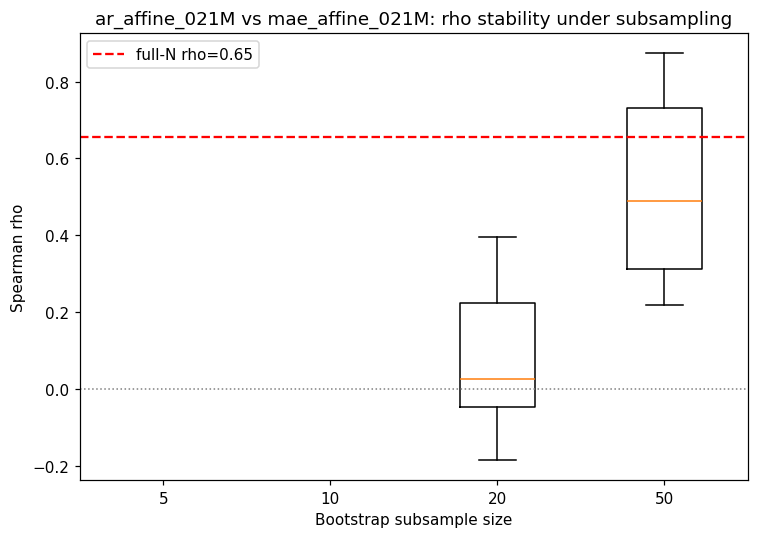


Fraction of bootstrap repeats significant at p<0.05, by subsample size:
subsample_size
5     0.0
10    0.0
20    0.0
50    0.3
Name: sig, dtype: float64


In [16]:
# --- 12. Bootstrap stability of a single pair's rho --------------------------

def bootstrap_rho_stability(name_A: str, name_B: str, tag: str = "trained",
                             subsample_sizes=BOOT_KS, n_repeat=N_BOOT_REPEAT,
                             k: int = K_MKNN, seed: int = RNG_SEED) -> pd.DataFrame:
    """For one model pair, redo the raw-correspondence + Spearman rho at each
    bootstrap subsample size and repeat, so we can see whether a headline rho
    computed at full N is stable or a fluke.
    """
    layers_A, names_A = ALL_DATA[(name_A, tag)], LAYER_ORDER[(name_A, tag)]
    layers_B, names_B = ALL_DATA[(name_B, tag)], LAYER_ORDER[(name_B, tag)]
    core_A = [n for n in names_A if n != "pixel_pca"]
    core_B = [n for n in names_B if n != "pixel_pca"]

    N_total = len(next(iter(layers_A.values())))
    local_rng = np.random.default_rng(seed)
    rows = []
    for size in subsample_sizes:
        size = min(size, N_total)
        for r in range(n_repeat):
            idx = local_rng.choice(N_total, size=size, replace=False)
            M_b, _ = alignment_matrix(layers_A, core_A, layers_B, core_B,
                                       k=min(k, size - 1), subset_idx=idx,
                                       seed=local_rng.integers(1e6), verbose=False)
            _, rho_b, p_b = raw_correspondence(M_b)
            rows.append({"subsample_size": size, "repeat": r, "rho": rho_b, "p": p_b})
        print(f"  size={size}: {n_repeat} repeats done")
    return pd.DataFrame(rows)

rho_stability = bootstrap_rho_stability("ar_affine_021M", "mae_affine_021M", tag="trained")

summary_by_size = rho_stability.groupby("subsample_size")["rho"].agg(["mean", "std", "min", "max"])
full_n_rho = mono_trained.loc[
    ((mono_trained.A == "ar_affine_021M") & (mono_trained.B == "mae_affine_021M")) |
    ((mono_trained.A == "mae_affine_021M") & (mono_trained.B == "ar_affine_021M")),
    "rho"
].values
print(f"Full-N rho (reference): {full_n_rho}")
display(summary_by_size)

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([rho_stability.loc[rho_stability.subsample_size == s, "rho"] for s in BOOT_KS],
           labels=[str(s) for s in BOOT_KS])
if len(full_n_rho):
    ax.axhline(full_n_rho[0], color="red", ls="--", label=f"full-N rho={full_n_rho[0]:.2f}")
ax.axhline(0, color="gray", ls=":", lw=1)
ax.set_xlabel("Bootstrap subsample size"); ax.set_ylabel("Spearman rho")
ax.set_title("ar_affine_021M vs mae_affine_021M: rho stability under subsampling")
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / "rho_stability_affine_pair.pdf")
plt.show()

frac_sig = rho_stability.assign(sig=rho_stability.p < 0.05).groupby("subsample_size")["sig"].mean()
print("\nFraction of bootstrap repeats significant at p<0.05, by subsample size:")
print(frac_sig)
